Communications for Development:
(Aditya) <br>Here's the rundown on our IDS narrative:<br>1. We're ditching the ERa attack. Professor is right in that it's way too narrow and theoretical, and that we need to base the IDS on more, or maybe at least make it more general.<br>2. We're combining two things: RMS maps from Li et al, and explainable AI from McCool et al (refer to project status report doc's literature review). Keep in mind, we're taking small snippets from their things, and not implementing their metrics/techniques fully. <br>3. We'll keep the dataset localized to Ninapro. It's clean and thorough.

So, what is our model going to look like?

First, we'll convert raw EMG data into 2D RMS (root mean square) maps.
Then, we'll have a convolutional autoencoder trained only on a user's normal gestures.

(Autoencoder: an encoder takes image data and converts it into an embedding that contains the model's extracted features from the image. Then, a decoder tries to reconstruct an image from the embedding.)

Normal data, when inputted through the autoencoder, should result in a reconstructed image that isn't totally exact to the original, but should still result in a low MSE reconstruction error, IF it's from the trained-on user.

However, when a new sample comes in (from, say, an intruder), and the autoencoder tries to reconstruct it, the features the encoder will process will come out differently, and after the decoder reconstructs it, this will result in a high MSE reconstruction error. This is how we flag our anomalies.

We're not finished. To make this error explainable, we're going to process the reconstruction error, and apply an XAI (explainable AI) technique like grad-CAM or SHAP to it (probably gradcam, computationally cheaper), creating a heatmap showing which pixels caused the anomaly. We'll implement it by calculating gradients relative to the reconstruction loss.
____________________________________________________
Still a few things to do: we need measurements of this vs different intruders, seeing if it could work for multiple people, and testing of signal anomaly vs intruder anomaly (all stuff to help pad our final report and presentation), so it plausibly looks like we've done something.
___________________________________________________________
(Davis) Using Aditya's first draft for the IDS, I've altered it such that the current version trains on multiple (2 for now) data files from Subject 1 and conducts evaluation against EMG data from Subject 2 and Subject 3. It also Evaluates against Subject 1's third file that I held out from training. I also have a script in the first cell that helps create the folders needed in content and will help setup when you open a new session. Currently, the evaluation metrics are pretty bad. Detection for S2 is at 25-41% (aiming for 80-90%) and S3 is 40-65%. The S1 holdout is even worse at around 19% (ideally less than 5%) so it could probably use a lot of tuning. We could add more layers but it could slow the training and runtime. Perhaps will test CNN 1D or some other approach if have time. We don't really have or are able to train with more data, even if we could it wouldn't be realistically implementable for each user if this was to be actually used in practice because they would spend a very long time just acquiring the data before the IDS becomes usable.
Possible things to try:
- Adjusting layers, the model might be small enough, we might not need to compress further since it is not very accurate at the moment
- Adjusting sliding window parameters, currently 200 ms, 50% overlap; larger or overlapping windows might capture more temporal patterns and improve detection
- Adjust threshold, increase to 97 or decrease to 92 to see if we can reach a better rejection rate for intruders or better acceptance rate for authorized users
- flow matching?
- 1D CNN?


I created a new section at the top called Implementation 3, basically near identical code but reorganized such that it is grouped into setup, helpers, execution, and visualization so that it is easier to adjust things for different experiments.

So far I've found that with the previous experiment using S1 E1 and E2 as input and testing against S2, S3, and withheld S1 data. An epoch of 15 has achieve the best results. After reorganizing the code and running experiment 2 where I used S1,2,3's E1 as input and compared against the E1 data for S4,5,6, I've found that perhaps due to the greater diversity of data, an epoch of 25 achieved better results compared to 15.

In [ ]:
#-----Start of Third Implementation (Reorganized for easier experimenting)------
import os
from pathlib import Path

def setup_directories():
    '''
    creates s1, s2, and s3 directories within content directory
    '''
    base_path = Path("/content/")
    directories = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10']

    print("Starting directory setup...")

    for directory_name in directories:
        dir_path = base_path / directory_name
        try:
            os.makedirs(dir_path, exist_ok=True)
            print(f"making directory '{dir_path}'")
        except OSError as e:
            print(f"error creating directory {dir_path}: {e}")

    print("\nsetup complete, next block will fill directories with data files.")

setup_directories()

Starting directory setup...
making directory '/content/s1'
making directory '/content/s2'
making directory '/content/s3'
making directory '/content/s4'
making directory '/content/s5'
making directory '/content/s6'
making directory '/content/s7'
making directory '/content/s8'
making directory '/content/s9'
making directory '/content/s10'

setup complete, next block will fill directories with data files.


In [ ]:
!pip install gdown

import os
import shutil
import zipfile
import re
import gdown

def process_ninapro_zip(url):
    file_id = url.split('/d/')[1].split('/')[0]
    download_url = f'https://drive.google.com/uc?id={file_id}'
    output_filename = "NinaPro_DB5.zip"

    print(f"Downloading {output_filename}...")
    # gdown handles the authentication/public link logic
    gdown.download(download_url, output_filename, quiet=False)

    # Unzip the file
    temp_extract_dir = "temp_unzipped_data"
    print(f"Unzipping to {temp_extract_dir}...")

    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall(temp_extract_dir)

    # Organize files into subject folders (s1, s2, ...)
    print("Organizing files...")

    # Walk through the unzipped contents
    for root, dirs, files in os.walk(temp_extract_dir):
        for filename in files:
            # Regex to match files starting with 'S' followed by a number
            # e.g., "S1_E1_A1.mat" -> matches "1"
            match = re.match(r"^S(\d+)_", filename)

            if match:
                subject_num = match.group(1)

                # Create directory s1, s2, etc. (lowercase)
                target_dir = f"s{subject_num}"
                os.makedirs(target_dir, exist_ok=True)

                # Move the file
                src_path = os.path.join(root, filename)
                dst_path = os.path.join(target_dir, filename)

                shutil.move(src_path, dst_path)
                print(f"Moved: {filename} -> {target_dir}/")

    # Clean up the temp folder
    shutil.rmtree(temp_extract_dir)
    print("\nSuccess! All files downloaded and organized.")

drive_link = "https://drive.google.com/file/d/1olaMVzA39C_RV8V8W1QHVb19Kzs9xn_2/view?usp=sharing"
process_ninapro_zip(drive_link)

Downloading...
From (original): https://drive.google.com/uc?id=1olaMVzA39C_RV8V8W1QHVb19Kzs9xn_2
From (redirected): https://drive.google.com/uc?id=1olaMVzA39C_RV8V8W1QHVb19Kzs9xn_2&confirm=t&uuid=3889e32d-b50a-431b-8c30-3162f876f087
To: /content/NinaPro_DB5.zip
100%|██████████| 202M/202M [00:03<00:00, 58.7MB/s]


Unzipping to temp_unzipped_data...
Organizing files...
Moved: S5_E2_A1.mat -> s5/
Moved: S8_E3_A1.mat -> s8/
Moved: S5_E3_A1.mat -> s5/
Moved: S4_E3_A1.mat -> s4/
Moved: S2_E1_A1.mat -> s2/
Moved: S7_E1_A1.mat -> s7/
Moved: S6_E1_A1.mat -> s6/
Moved: S10_E3_A1.mat -> s10/
Moved: S4_E2_A1.mat -> s4/
Moved: S1_E3_A1.mat -> s1/
Moved: S1_E2_A1.mat -> s1/
Moved: S5_E1_A1.mat -> s5/
Moved: S3_E1_A1.mat -> s3/
Moved: S7_E2_A1.mat -> s7/
Moved: S2_E3_A1.mat -> s2/
Moved: S9_E3_A1.mat -> s9/
Moved: S10_E2_A1.mat -> s10/
Moved: S2_E2_A1.mat -> s2/
Moved: S6_E2_A1.mat -> s6/
Moved: S8_E2_A1.mat -> s8/
Moved: S3_E2_A1.mat -> s3/
Moved: S1_E1_A1.mat -> s1/
Moved: S10_E1_A1.mat -> s10/
Moved: S7_E3_A1.mat -> s7/
Moved: S4_E1_A1.mat -> s4/
Moved: S9_E1_A1.mat -> s9/
Moved: S8_E1_A1.mat -> s8/
Moved: S9_E2_A1.mat -> s9/
Moved: S6_E3_A1.mat -> s6/
Moved: S3_E3_A1.mat -> s3/

Success! All files downloaded and organized.


In [ ]:
# ============================
# Helper Functions
# ============================

import os, glob
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, losses

# --- MAT file loader ---
def load_ninapro_file(file_path):
    try:
        data = scipy.io.loadmat(file_path, simplify_cells=True)
    except Exception as e:
        raise RuntimeError(f"Failed to load MAT file {file_path}: {e}")

    emg_keys = ['emg', 'EMG', 'emg_signal', 'EMGsignal']
    stim_keys = ['stimulus', 'stim', 'stimuli', 'labels']
    rep_keys = ['repetition', 'reps', 'repetition_label']

    def find_key(d, candidates):
        for k in candidates:
            if k in d:
                return k
        return None

    emg_key = find_key(data, emg_keys)
    stim_key = find_key(data, stim_keys)
    rep_key = find_key(data, rep_keys)

    if emg_key is None:
        raise KeyError(f"No EMG key found in {file_path}. Found keys: {list(data.keys())}")

    emg = np.asarray(data[emg_key])
    stim = np.asarray(data[stim_key]) if stim_key else None
    rep = np.asarray(data[rep_key]) if rep_key else None

    if emg.ndim == 2 and emg.shape[0] < emg.shape[1]:
        emg = emg.T

    print(f"[LOAD] {os.path.basename(file_path)} -> EMG shape: {emg.shape}")
    return emg, stim, rep

# --- Directory & file helpers ---
def subject_dir(base_path, subject_name):
    return os.path.join(base_path, subject_name)

def list_mat_files(subject_path):
    return sorted(glob.glob(os.path.join(subject_path, '*.mat')))

def load_selected_mat_files(file_list):
    emg_list, stim_list, rep_list = [], [], []
    for f in file_list:
        emg, stim, rep = load_ninapro_file(f)
        emg_list.append(emg)
        stim_list.append(stim)
        rep_list.append(rep)
    if len(emg_list) == 0:
        raise FileNotFoundError("No files provided to load_selected_mat_files")
    emg_all = np.vstack(emg_list)
    return emg_all, stim_list, rep_list

# --- Plot subject experiments (quick visualization helper) ---
def plot_subject_experiments(base_dir, channel=0, samples=1000):
    subject_files = sorted(glob.glob(os.path.join(base_dir, "*.mat")))
    if len(subject_files) == 0:
        print(f"[ERROR] No .mat files found in {base_dir}/")
        return

    plt.figure(figsize=(12, 5))
    for f in subject_files:
        emg, stim, rep = load_ninapro_file(f)
        length = min(samples, emg.shape[0])
        plt.plot(emg[:length, channel], label=os.path.basename(f))

    plt.title(f"{base_dir.upper()} — First {samples} Samples (Channel {channel+1})")
    plt.xlabel("Sample Index")
    plt.ylabel("EMG Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- RMS Image creation ---
def create_rms_images(emg_data, window_size, step_size):
    rms_images = []
    for i in range(0, len(emg_data) - window_size, step_size):
        window = emg_data[i : i + window_size]
        rms_vector = np.sqrt(np.mean(window**2, axis=0))
        if rms_vector.size != 16:
            raise ValueError(f"Expected 16 channels, got {rms_vector.size} at window {i}")
        rms_image = rms_vector.reshape(2, 8)
        if np.max(rms_image) > 0:
            rms_image = rms_image / np.max(rms_image)
            #rms_image = rms_image / 95.53742980957031
        rms_images.append(rms_image)
    return np.array(rms_images)

# --- Autoencoder model builder ---
def build_tiny_emg_autoencoder(input_shape=(2, 8, 1)):
    input_img = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, (2, 2), padding='same', activation='relu')(input_img)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(8, (2, 2), strides=(1, 2), padding='same', activation='relu')(x)
    volume_size = tf.keras.backend.int_shape(x)
    x = layers.Flatten()(x)
    encoded = layers.Dense(8, activation='relu', name='latent_space')(x)
    x = layers.Dense(np.prod(volume_size[1:]), activation='relu')(encoded)
    x = layers.Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)
    x = layers.Conv2DTranspose(8, (2, 2), strides=(1, 2), padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(16, (2, 2), padding='same', activation='relu')(x)
    decoded = layers.Conv2D(1, (2, 2), activation='sigmoid', padding='same', name='output')(x)
    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

# --- Evaluation helpers ---
def evaluate_files(file_list, model, threshold, name="Unnamed"):
    print("\n--- EVALUATION:", name, "---")
    results = []
    for f in file_list:
        print("Processing:", os.path.basename(f))
        raw_emg, _, _ = load_ninapro_file(f)
        X_images = create_rms_images(raw_emg, window_samples, step_samples)
        X_images = X_images[..., np.newaxis]
        recon = model.predict(X_images)
        losses = tf.reduce_mean(tf.square(X_images - recon), axis=(1,2,3)).numpy()
        mean_loss = np.mean(losses)
        detections = losses > threshold
        detection_rate = np.mean(detections) * 100
        print(f"  Num images: {len(losses)}, Mean loss: {mean_loss:.6f}, Detection rate: {detection_rate:.2f}%")
        results.append({
            'file': os.path.basename(f),
            'n_images': int(len(losses)),
            'mean_loss': float(mean_loss),
            'detection_rate_pct': float(detection_rate)
        })
    return results

# --- Summarize EMG files ---
def emg_file_summary(subject_dir, subject_name):
    files = list_mat_files(subject_dir)
    summary = []
    for f in files:
        emg, stim, rep = load_ninapro_file(f)
        summary.append({'file': os.path.basename(f),'samples': emg.shape[0],'channels': emg.shape[1]})
    df = pd.DataFrame(summary)
    print(f"\n{subject_name.upper()} EMG Summary:")
    display(df)

# --- EER Helper Function ---
def compute_eer(authorized_losses, intruder_losses):
    all_losses = np.concatenate([authorized_losses, intruder_losses])
    thresholds = np.linspace(np.min(all_losses), np.max(all_losses), 1000)

    frr_list = []  # False Rejection Rate
    far_list = []  # False Acceptance Rate

    for t in thresholds:
        frr = np.mean(authorized_losses > t)
        far = np.mean(intruder_losses <= t)
        frr_list.append(frr)
        far_list.append(far)

    frr_list = np.array(frr_list)
    far_list = np.array(far_list)

    # Find threshold where |FAR - FRR| is minimal
    idx = np.argmin(np.abs(frr_list - far_list))
    eer_threshold = thresholds[idx]
    eer = np.mean([frr_list[idx], far_list[idx]])

    return eer, eer_threshold


print("Helper functions loaded successfully. You can now proceed to execution cell.")

Helper functions loaded successfully. You can now proceed to execution cell.


In [ ]:
# ============================
# Execution Cell: Load Data, Train Model, Compute Thresholds
# ============================

# --- Base paths ---
BASE_CONTENT_DIR = '/content'
S1_DIR = subject_dir(BASE_CONTENT_DIR, 's1')
S2_DIR = subject_dir(BASE_CONTENT_DIR, 's2')
S3_DIR = subject_dir(BASE_CONTENT_DIR, 's3')
S4_DIR = subject_dir(BASE_CONTENT_DIR, 's4')
S5_DIR = subject_dir(BASE_CONTENT_DIR, 's5')
S6_DIR = subject_dir(BASE_CONTENT_DIR, 's6')
#S7_DIR = subject_dir(BASE_CONTENT_DIR, 's7')
#S8_DIR = subject_dir(BASE_CONTENT_DIR, 's8')
#S9_DIR = subject_dir(BASE_CONTENT_DIR, 's9')
#S10_DIR = subject_dir(BASE_CONTENT_DIR, 's10')

# --- List files ---
s1_files = list_mat_files(S1_DIR)
s2_files = list_mat_files(S2_DIR)
s3_files = list_mat_files(S3_DIR)
print("S1 files:", [os.path.basename(f) for f in s1_files])
print("S2 files:", [os.path.basename(f) for f in s2_files])
print("S3 files:", [os.path.basename(f) for f in s3_files])

# --- Training selection ---
#train_files_s1 = s1_files[:2]
train_files = [
    s1_files[0],
    s2_files[0],
    s3_files[0]
]
#holdout_file_s1 = s1_files[2]
holdout_file_s2_e2 = s2_files[0]

# --- Intruder Files ---
s4_files = list_mat_files(S4_DIR) [0]
s5_files = list_mat_files(S5_DIR) [0]
s6_files = list_mat_files(S6_DIR) [0]

raw_emg_train, stim_train_list, reps_train_list = load_selected_mat_files(train_files)
print("raw_emg_train shape:", raw_emg_train.shape)

# --- RMS windowing parameters ---
fs = 200
win_len_ms = 200
window_samples = int(fs * (win_len_ms / 1000))
step_samples = 20

# --- Create RMS images ---
X_train_images = create_rms_images(raw_emg_train, window_samples, step_samples)
X_train_images = X_train_images[..., np.newaxis]
print("X_train_images shape:", X_train_images.shape)

# --- Build model ---
model = build_tiny_emg_autoencoder(input_shape=(2,8,1))
model.summary()

# --- Train model ---
X_train, X_val = train_test_split(X_train_images, test_size=0.1, random_state=42)
noise_factor = .1
X_train_noisy = np.clip(X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape), 0., 1.)
history = model.fit(
    X_train, X_train,
    validation_data=(X_train_noisy, X_train),
    epochs=25,
    batch_size=32,
    shuffle=True
)

# --- Compute threshold ---
user_recon_val = model.predict(X_val)
user_val_losses = tf.reduce_mean(tf.square(X_val - user_recon_val), axis=(1,2,3)).numpy()
threshold = np.percentile(user_val_losses, 95)
print("Validation mean loss:", np.mean(user_val_losses))
print("Threshold (95th percentile):", threshold)

# --- Summaries ---
emg_file_summary(S1_DIR, 's1')
emg_file_summary(S2_DIR, 's2')
emg_file_summary(S3_DIR, 's3')

# --- Evaluation outputs ---
#res_s2 = evaluate_files(s2_files, model, threshold, name="Subject s2 (intruder)")
#res_s3 = evaluate_files(s3_files, model, threshold, name="Subject s3 (intruder)")
#res_s1_holdout = evaluate_files([holdout_file_s1], model, threshold, name="Subject s1 holdout")
res_s4 = evaluate_files([s4_files], model, threshold, name="Subject s4 (intruder)")
res_s5 = evaluate_files([s5_files], model, threshold, name="Subject s5 (intruder)")
res_s6 = evaluate_files([s6_files], model, threshold, name="Subject s6 (intruder)")
res_s2_holdout_e2 = evaluate_files([holdout_file_s2_e2], model, threshold, name="Subject s2 holdout (authorized)")

S1 files: ['S1_E1_A1.mat', 'S1_E2_A1.mat', 'S1_E3_A1.mat']
S2 files: ['S2_E1_A1.mat', 'S2_E2_A1.mat', 'S2_E3_A1.mat']
S3 files: ['S3_E1_A1.mat', 'S3_E2_A1.mat', 'S3_E3_A1.mat']
[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
[LOAD] S3_E1_A1.mat -> EMG shape: (131366, 16)
raw_emg_train shape: (410000, 16)
X_train_images shape: (20498, 2, 8, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 2, 8, 16)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2, 8, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 4, 8)        │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 2, 8, 8)        │           264 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 2, 8, 16)       │           528 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 2, 8, 1)        │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617 (10.22 KB)

 Trainable params: 2,585 (10.10 KB)

...

[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
[LOAD] S2_E2_A1.mat -> EMG shape: (203945, 16)
[LOAD] S2_E3_A1.mat -> EMG shape: (292932, 16)

S2 EMG Summary:


,file,samples,channels
0,S2_E1_A1.mat,148367,16
1,S2_E2_A1.mat,203945,16
2,S2_E3_A1.mat,292932,16


[LOAD] S3_E1_A1.mat -> EMG shape: (131366, 16)
[LOAD] S3_E2_A1.mat -> EMG shape: (184429, 16)
[LOAD] S3_E3_A1.mat -> EMG shape: (260036, 16)

S3 EMG Summary:


,file,samples,channels
0,S3_E1_A1.mat,131366,16
1,S3_E2_A1.mat,184429,16
2,S3_E3_A1.mat,260036,16



--- EVALUATION: Subject s4 (intruder) ---
Processing: S4_E1_A1.mat
[LOAD] S4_E1_A1.mat -> EMG shape: (151664, 16)
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Num images: 7582, Mean loss: 0.006779, Detection rate: 34.54%

--- EVALUATION: Subject s5 (intruder) ---
Processing: S5_E1_A1.mat
[LOAD] S5_E1_A1.mat -> EMG shape: (148526, 16)
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Num images: 7425, Mean loss: 0.004986, Detection rate: 22.34%

--- EVALUATION: Subject s6 (intruder) ---
Processing: S6_E1_A1.mat
[LOAD] S6_E1_A1.mat -> EMG shape: (151793, 16)
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Num images: 7588, Mean loss: 0.020784, Detection rate: 79.65%

--- EVALUATION: Subject s2 holdout (authorized) ---
Processing: S2_E1_A1.mat
[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  Num images: 7417, Mean loss: 0.002185, Detection rate: 3.41%


In [ ]:
print(s1_files)

#Keep the first 2 files in s1_files, use the third as a hold-out file
holdout_file_s1 = s1_files[2]
s1_files = s1_files[:2]
print(s1_files)
print(holdout_file_s1)

['/content/s1/S1_E1_A1.mat', '/content/s1/S1_E2_A1.mat', '/content/s1/S1_E3_A1.mat']
['/content/s1/S1_E1_A1.mat', '/content/s1/S1_E2_A1.mat']
/content/s1/S1_E3_A1.mat


[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S1_E2_A1.mat -> EMG shape: (179901, 16)
[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
[LOAD] S2_E2_A1.mat -> EMG shape: (203945, 16)
[LOAD] S2_E3_A1.mat -> EMG shape: (292932, 16)
[LOAD] S3_E1_A1.mat -> EMG shape: (131366, 16)
[LOAD] S3_E2_A1.mat -> EMG shape: (184429, 16)
[LOAD] S3_E3_A1.mat -> EMG shape: (260036, 16)
[LOAD] S1_E3_A1.mat -> EMG shape: (258372, 16)

Threshold (95th percentile of Authorized User): 0.01621


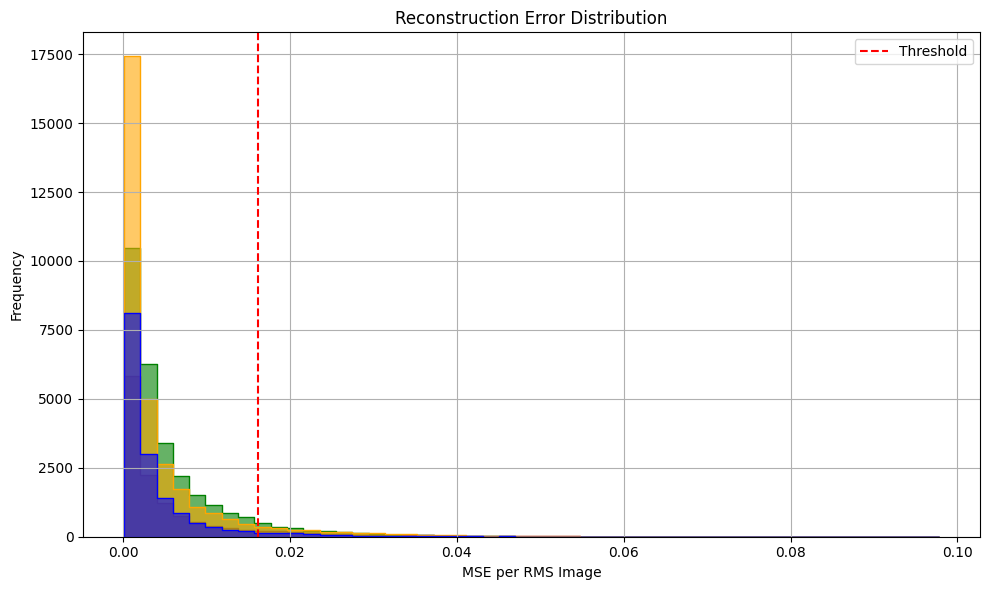

/tmp/ipython-input-3453337430.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_losses, x='Subject', y='MSE', palette=['blue','orange','green','purple'])


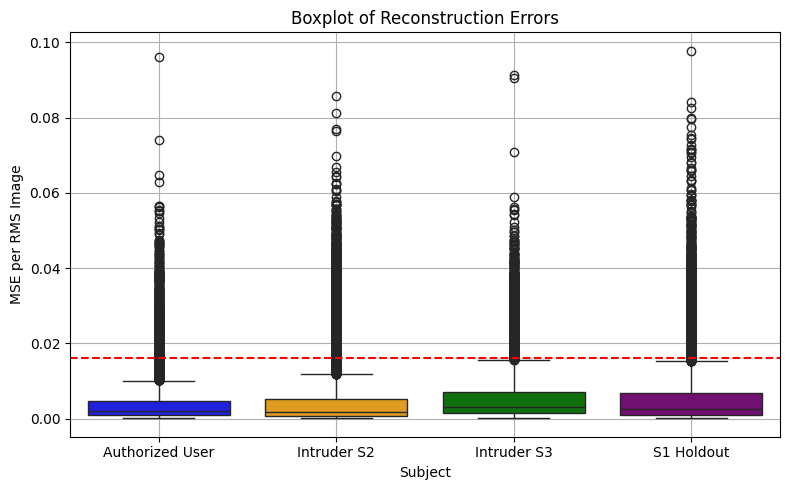

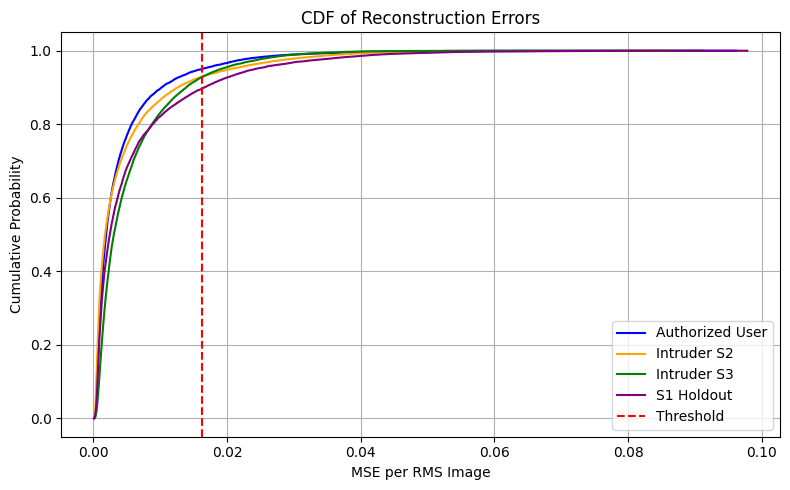

/tmp/ipython-input-3453337430.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(rates.keys()), y=list(rates.values()), palette=['orange','green','purple'])


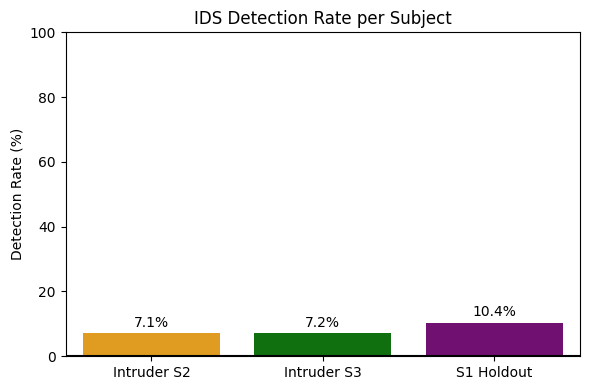

Intruder S2 EER: 51.22% at threshold 0.00186


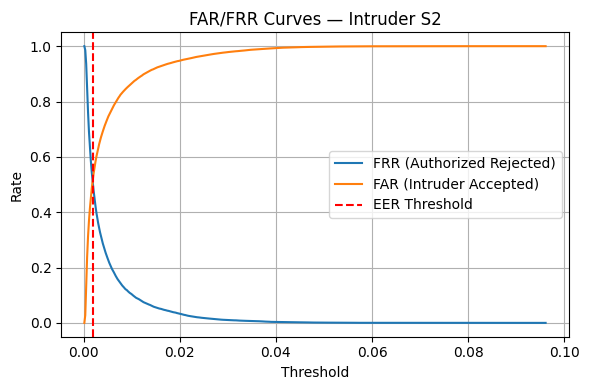

Intruder S3 EER: 42.24% at threshold 0.00241


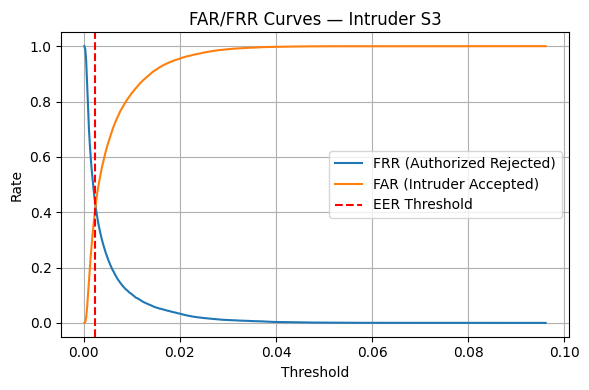

In [ ]:
# ============================
# Visualization Cell: Charts and Graphs (Note: not yet adjusted to match output eval metrics for experiment 2)
# ============================

import seaborn as sns

# --- Helper: convert list of files to RMS images ---
def files_to_rms_array(file_list):
    emg_all, _, _ = load_selected_mat_files(file_list)
    rms_images = create_rms_images(emg_all, window_samples, step_samples)
    return rms_images[..., np.newaxis]

# --- Prepare data ---
X_val = files_to_rms_array(s1_files)          # Authorized User
X_s2 = files_to_rms_array(s2_files)                 # Intruder S2
X_s3 = files_to_rms_array(s3_files)                 # Intruder S3
X_s1_holdout = files_to_rms_array([holdout_file_s1]) # Held-out S1

def ensure_4d(X):
    return X if X.ndim == 4 else X[..., np.newaxis]

X_val = ensure_4d(X_val)
X_s2 = ensure_4d(X_s2)
X_s3 = ensure_4d(X_s3)
X_s1_holdout = ensure_4d(X_s1_holdout)

# --- Compute losses ---
def compute_losses(model, X):
    recon = model.predict(X, verbose=0)
    return tf.reduce_mean(tf.square(X - recon), axis=(1,2,3)).numpy()

loss_val = compute_losses(model, X_val)
loss_s2 = compute_losses(model, X_s2)
loss_s3 = compute_losses(model, X_s3)
loss_s1_holdout = compute_losses(model, X_s1_holdout)

# --- Threshold ---
threshold = np.percentile(loss_val, 95)
print(f"\nThreshold (95th percentile of Authorized User): {threshold:.5f}")

# --- Prepare dataframe for plots ---
loss_data = []
for losses, subject in zip([loss_val, loss_s2, loss_s3, loss_s1_holdout],
                           ['Authorized User','Intruder S2','Intruder S3','S1 Holdout']):
    loss_data.extend([{'Subject': subject, 'MSE': l} for l in losses])
df_losses = pd.DataFrame(loss_data)

# --- Histogram ---
plt.figure(figsize=(10,6))
sns.histplot(data=df_losses, x='MSE', hue='Subject', bins=50, palette=['blue','orange','green','purple'], alpha=0.6, element='step', stat='count')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE per RMS Image")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Boxplot ---
plt.figure(figsize=(8,5))
sns.boxplot(data=df_losses, x='Subject', y='MSE', palette=['blue','orange','green','purple'])
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("Boxplot of Reconstruction Errors")
plt.ylabel("MSE per RMS Image")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- CDF ---
plt.figure(figsize=(8,5))
for subject, color in zip(['Authorized User','Intruder S2','Intruder S3','S1 Holdout'],
                          ['blue','orange','green','purple']):
    sorted_losses = np.sort(df_losses[df_losses['Subject']==subject]['MSE'].values)
    cdf = np.arange(len(sorted_losses))/len(sorted_losses)
    plt.plot(sorted_losses, cdf, label=subject, color=color)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("CDF of Reconstruction Errors")
plt.xlabel("MSE per RMS Image")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Detection rates ---
rates = {subject: np.mean(df_losses[df_losses['Subject']==subject]['MSE'].values > threshold)*100
         for subject in ['Intruder S2','Intruder S3','S1 Holdout']}

plt.figure(figsize=(6,4))
sns.barplot(x=list(rates.keys()), y=list(rates.values()), palette=['orange','green','purple'])
plt.axhline(0, color='black')
plt.ylabel("Detection Rate (%)")
plt.title("IDS Detection Rate per Subject")
plt.ylim(0,100)
for i, v in enumerate(rates.values()):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# --- Equal Error Rate (EER) Visualization ---
# Compute EER for each intruder subject vs authorized user
for intruder_X, intruder_name in zip([X_s2, X_s3], ['Intruder S2','Intruder S3']):
    authorized_losses = loss_val  # Authorized user
    intruder_losses = compute_losses(model, intruder_X)

    eer, eer_threshold = compute_eer(authorized_losses, intruder_losses)
    print(f"{intruder_name} EER: {eer*100:.2f}% at threshold {eer_threshold:.5f}")

    # Plot FAR and FRR curves
    thresholds = np.linspace(min(min(authorized_losses), min(intruder_losses)),
                             max(max(authorized_losses), max(intruder_losses)), 500)
    frr_list = [np.mean(authorized_losses > t) for t in thresholds]
    far_list = [np.mean(intruder_losses <= t) for t in thresholds]

    plt.figure(figsize=(6,4))
    plt.plot(thresholds, frr_list, label='FRR (Authorized Rejected)')
    plt.plot(thresholds, far_list, label='FAR (Intruder Accepted)')
    plt.axvline(eer_threshold, color='red', linestyle='--', label=f'EER Threshold')
    plt.title(f"FAR/FRR Curves — {intruder_name}")
    plt.xlabel("Threshold")
    plt.ylabel("Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #------------End of Third Implementation (Reorg code)-----------------------

In [ ]:
'''
-------------------------- Start of Second Implementation --------------------------
DB Setup Script:
  Makes 3 directories s1, s2, s3 for 3 subjects, my attempts at automating the
  data loading process were unsuccessful, this is temporary method.
  Data file can be downloaded and unzipped from here
  https://ninapro.hevs.ch/instructions/DB5.html.
'''
import os
from pathlib import Path

def setup_directories():
    '''
    creates s1, s2, and s3 directories within content directory
    '''
    base_path = Path("/content/")
    directories = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10']

    print("Starting directory setup...")

    for directory_name in directories:
        # construct the full path for the directory
        dir_path = base_path / directory_name

        try:
            # create the directory
            os.makedirs(dir_path, exist_ok=True)
            print(f"making directory '{dir_path}'")
        except OSError as e:
            print(f"error creating directory {dir_path}: {e}")

    print("\nsetup complete, need to fill directories with data files.")

# run the setup function
setup_directories()

Starting directory setup...
making directory '/content/s1'
making directory '/content/s2'
making directory '/content/s3'
making directory '/content/s4'
making directory '/content/s5'
making directory '/content/s6'
making directory '/content/s7'
making directory '/content/s8'
making directory '/content/s9'
making directory '/content/s10'

setup complete, need to fill directories with data files.


[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S1_E2_A1.mat -> EMG shape: (179901, 16)
[LOAD] S1_E3_A1.mat -> EMG shape: (258372, 16)


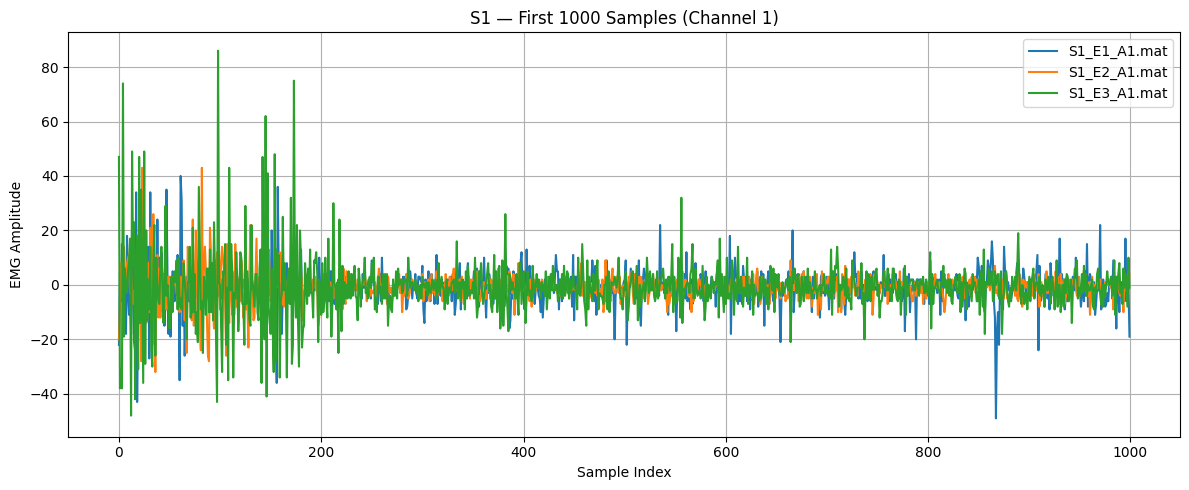

[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
[LOAD] S2_E2_A1.mat -> EMG shape: (203945, 16)
[LOAD] S2_E3_A1.mat -> EMG shape: (292932, 16)


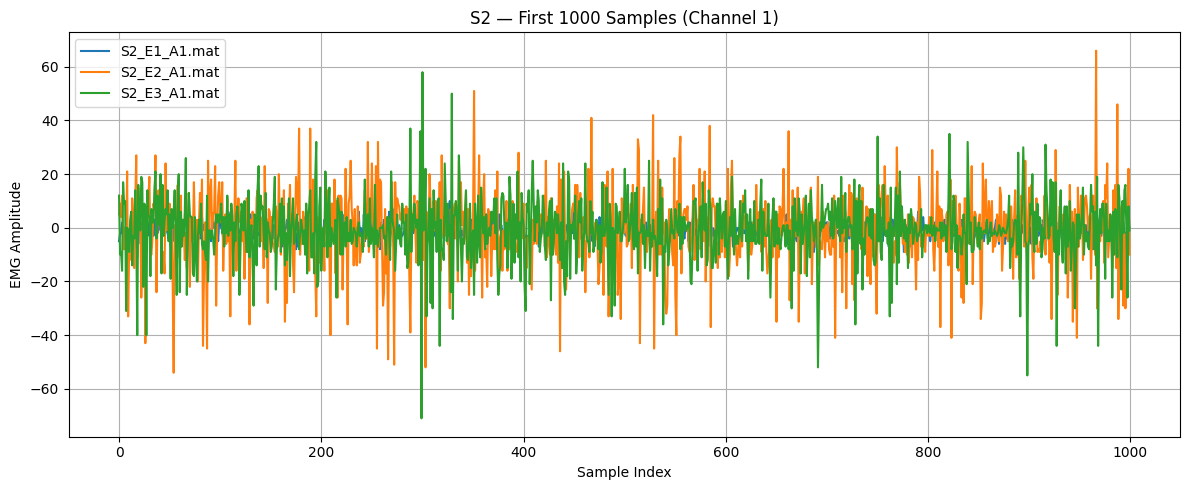

In [ ]:
#------------------------Second Implementation Continued-------------------------
# imports and MAT loader
import os, glob
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# new loader that returns emg (samples x channels), stimulus, repetition
def load_ninapro_file(file_path):
    try:
        data = scipy.io.loadmat(file_path, simplify_cells=True)
    except Exception as e:
        raise RuntimeError(f"Failed to load MAT file {file_path}: {e}")

    # candidate keys
    emg_keys = ['emg', 'EMG', 'emg_signal', 'EMGsignal']
    stim_keys = ['stimulus', 'stim', 'stimuli', 'labels']
    rep_keys = ['repetition', 'reps', 'repetition_label']

    def find_key(d, candidates):
        for k in candidates:
            if k in d:
                return k
        return None

    emg_key = find_key(data, emg_keys)
    stim_key = find_key(data, stim_keys)
    rep_key = find_key(data, rep_keys)

    if emg_key is None:
        raise KeyError(f"No EMG key found in {file_path}. Found keys: {list(data.keys())}")

    emg = np.asarray(data[emg_key])
    stim = np.asarray(data[stim_key]) if stim_key else None
    rep = np.asarray(data[rep_key]) if rep_key else None

    # If EMG is shaped (channels, samples) convert to (samples, channels)
    if emg.ndim == 2 and emg.shape[0] < emg.shape[1]:
        emg = emg.T

    print(f"[LOAD] {os.path.basename(file_path)} -> EMG shape: {emg.shape}")
    return emg, stim, rep

# Helper method: plot first N samples from a given subject directory
def plot_subject_experiments(base_dir, channel=0, samples=1000):
    """
    Loads all .mat files inside the subject directory (e.g., 's1/')
    and plots the first `samples` samples of the selected channel
    for each experiment file.
    """
    # Get all mat files (S1_E1_A1.mat, S1_E2_A1.mat, etc.)
    subject_files = sorted(glob.glob(os.path.join(base_dir, "*.mat")))

    if len(subject_files) == 0:
        print(f"[ERROR] No .mat files found in {base_dir}/")
        return

    plt.figure(figsize=(12, 5))

    for f in subject_files:
        emg, stim, rep = load_ninapro_file(f)

        # Protect against short signals
        length = min(samples, emg.shape[0])

        label = os.path.basename(f)

        # Plot first samples from selected channel
        plt.plot(emg[:length, channel], label=label)

    subject_name = base_dir.upper()
    plt.title(f"{subject_name} — First {samples} Samples (Channel {channel+1})")
    plt.xlabel("Sample Index")
    plt.ylabel("EMG Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# generate graphs for subject 1 and 2

# plot subject 1
plot_subject_experiments(base_dir="s1", channel=0, samples=1000)

# plot subject 2
plot_subject_experiments(base_dir="s2", channel=0, samples=1000)

In [ ]:
#------------------------Second Implementation Continued------------------------
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, losses

# NOTE: We can swing this as a high-efficiency model deployable on IoT devices,
# thanks to low # of parameters.
def build_tiny_emg_autoencoder(input_shape=(2, 8, 1)):
    """
    Builds a Tiny-CNN Autoencoder optimized for 2x8 EMG RMS maps.
    """
    # --- ENCODER ---
    # Compresses the 2x8 anatomical map into a small latent vector
    input_img = layers.Input(shape=input_shape)

    # layer 1: Spatial Feature Extraction
    # We use 'same' padding to keep the 2x8 dimensions initially
    x = layers.Conv2D(16, (2, 2), padding='same', activation='relu')(input_img)
    x = layers.BatchNormalization()(x)

    # layer 2: Compression
    # We use (1, 2) strides to compress WIDTH (8->4) but keep HEIGHT (2)
    # because 2 pixels is already very small.
    x = layers.Conv2D(8, (2, 2), strides=(1, 2), padding='same', activation='relu')(x) # Output: (2, 4, 8)

    # Flatten for the Bottleneck
    volume_size = tf.keras.backend.int_shape(x) # Save shape for decoding
    x = layers.Flatten()(x)

    # Latent Space (Bottleneck)
    # This is the condensed 'signature' of the user's movement
    encoded = layers.Dense(8, activation='relu', name='latent_space')(x)

    # DECODER
    # Attempts to reconstruct the original map from the latent signature
    x = layers.Dense(np.prod(volume_size[1:]), activation='relu')(encoded)
    x = layers.Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)

    # Inverse of Layer 2 (Upsampling width back to 8)
    x = layers.Conv2DTranspose(8, (2, 2), strides=(1, 2), padding='same', activation='relu')(x)

    # Inverse of Layer 1
    x = layers.Conv2DTranspose(16, (2, 2), padding='same', activation='relu')(x)

    # Output Layer
    # Sigmoid activation is used because inputs are normalized 0-1
    decoded = layers.Conv2D(1, (2, 2), activation='sigmoid', padding='same', name='output')(x)

    # Combine into Model
    autoencoder = models.Model(input_img, decoded)

    # Compile
    # MSE is critical: it measures the "Reconstruction Error" used for detection
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

# Instantiate and summary
# Note the '1' at the end for the channel dimension (grayscale)
model = build_tiny_emg_autoencoder(input_shape=(2, 8, 1))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 8, 16)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 8, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 4, 8)        │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 2, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 2, 8, 8)        │           264 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 2, 8, 16)       │           528 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 2, 8, 1)        │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617 (10.22 KB)

 Trainable params: 2,585 (10.10 KB)

 Non-trainable params: 32 (128.00 B)

[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S1_E2_A1.mat -> EMG shape: (179901, 16)
Created 15507 RMS images from first 2 S1 files
Shape of single image: (2, 8)


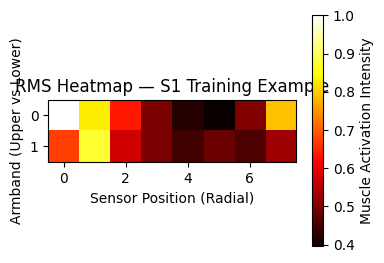

In [ ]:
#------------------------Second Implementation Continued------------------------
import numpy as np
import matplotlib.pyplot as plt

def create_rms_images(emg_data, window_size, step_size):
    """
    Converts raw EMG signal (Samples x 16) into RMS images (N x 2 x 8)
    """
    rms_images = []

    for i in range(0, len(emg_data) - window_size, step_size):
        window = emg_data[i : i + window_size]

        rms_vector = np.sqrt(np.mean(window**2, axis=0))

        # Check channel count
        if rms_vector.size != 16:
            raise ValueError(f"Expected 16 channels, got {rms_vector.size} at window {i}")

        # Reshape to 2x8
        rms_image = rms_vector.reshape(2, 8)

        # Normalize
        if np.max(rms_image) > 0:
            rms_image = rms_image / np.max(rms_image)

        rms_images.append(rms_image)

    return np.array(rms_images)

# RMS windowing parameters
fs = 200
win_len_ms = 200
window_samples = int(fs * (win_len_ms / 1000))  # 40 samples
step_samples = 20  # 50% overlap

# Load first 2 S1 files for training
s1_files = sorted(glob.glob(os.path.join("s1", "*.mat")))
# we're training on the first 2 data files only so we can test the third
train_files_s1 = s1_files[:2]

emg_list = []
for f in train_files_s1:
    emg, stim, rep = load_ninapro_file(f)
    emg_list.append(emg)

raw_emg_train = np.vstack(emg_list)  # concatenate along samples axis

# Create RMS images
X_train_images = create_rms_images(raw_emg_train, window_samples, step_samples)
print(f"Created {len(X_train_images)} RMS images from first 2 S1 files")
print(f"Shape of single image: {X_train_images[0].shape}")  # Should be (2,8)

# RMS image heat map
plt.figure(figsize=(4,3))
plt.imshow(X_train_images[100], cmap='hot', interpolation='nearest')
plt.title("RMS Heatmap — S1 Training Example")
plt.colorbar(label="Muscle Activation Intensity")
plt.ylabel("Armband (Upper vs Lower)")
plt.xlabel("Sensor Position (Radial)")
plt.show()

In [ ]:
#------------------------Second Implementation Continued------------------------
# Helper functions to help load multiple data files for each subject and pick specific
# files along with configuring folder locations & RMS params

import os, glob
import scipy.io
import numpy as np
import pandas as pd

# Helper functions
def subject_dir(base_path, subject_name):
    return os.path.join(base_path, subject_name)

def list_mat_files(subject_path):
    return sorted(glob.glob(os.path.join(subject_path, '*.mat')))

def load_selected_mat_files(file_list):
    """Load list of .mat file paths, return concatenated EMG (vstack) and list of stim/reps."""
    emg_list = []
    stim_list = []
    rep_list = []
    for f in file_list:
        emg, stim, rep = load_ninapro_file(f)
        emg_list.append(emg)
        stim_list.append(stim)
        rep_list.append(rep)
    if len(emg_list) == 0:
        raise FileNotFoundError("No files provided to load_selected_mat_files")
    emg_all = np.vstack(emg_list)
    return emg_all, stim_list, rep_list

# Base paths
BASE_CONTENT_DIR = '/content'
S1_DIR = subject_dir(BASE_CONTENT_DIR, 's1')
S2_DIR = subject_dir(BASE_CONTENT_DIR, 's2')
S3_DIR = subject_dir(BASE_CONTENT_DIR, 's3')

# List files
print("S1 files:", list_mat_files(S1_DIR))
print("S2 files:", list_mat_files(S2_DIR))
print("S3 files:", list_mat_files(S3_DIR))

# Load first 2 S1 files for training
train_files_s1 = list_mat_files(S1_DIR)[:2]
raw_emg_train, stim_list, rep_list = load_selected_mat_files(train_files_s1)
print("\nSanity Check: Loaded training EMG shape (concatenated 2 files):", raw_emg_train.shape)

# RMS windowing parameters
fs = 200
win_len_ms = 200
window_samples = int(fs * (win_len_ms / 1000))  # 40 samples
step_samples = 20  # 50% overlap

# Sanity check data visualization
def emg_file_summary(subject_dir, subject_name):
    files = list_mat_files(subject_dir)
    summary = []
    for f in files:
        emg, stim, rep = load_ninapro_file(f)
        summary.append({
            'file': os.path.basename(f),
            'samples': emg.shape[0],
            'channels': emg.shape[1]
        })
    df = pd.DataFrame(summary)
    print(f"\n{subject_name.upper()} EMG Summary:")
    display(df)

# Run summary for each subject
emg_file_summary(S1_DIR, 's1')
emg_file_summary(S2_DIR, 's2')
emg_file_summary(S3_DIR, 's3')


S1 files: ['/content/s1/S1_E1_A1.mat', '/content/s1/S1_E2_A1.mat', '/content/s1/S1_E3_A1.mat']
S2 files: ['/content/s2/S2_E1_A1.mat', '/content/s2/S2_E2_A1.mat', '/content/s2/S2_E3_A1.mat']
S3 files: ['/content/s3/S3_E1_A1.mat', '/content/s3/S3_E2_A1.mat', '/content/s3/S3_E3_A1.mat']
[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S1_E2_A1.mat -> EMG shape: (179901, 16)

Sanity Check: Loaded training EMG shape (concatenated 2 files): (310168, 16)
[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S1_E2_A1.mat -> EMG shape: (179901, 16)
[LOAD] S1_E3_A1.mat -> EMG shape: (258372, 16)

S1 EMG Summary:


,file,samples,channels
0,S1_E1_A1.mat,130267,16
1,S1_E2_A1.mat,179901,16
2,S1_E3_A1.mat,258372,16


[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
[LOAD] S2_E2_A1.mat -> EMG shape: (203945, 16)
[LOAD] S2_E3_A1.mat -> EMG shape: (292932, 16)

S2 EMG Summary:


,file,samples,channels
0,S2_E1_A1.mat,148367,16
1,S2_E2_A1.mat,203945,16
2,S2_E3_A1.mat,292932,16


[LOAD] S3_E1_A1.mat -> EMG shape: (131366, 16)
[LOAD] S3_E2_A1.mat -> EMG shape: (184429, 16)
[LOAD] S3_E3_A1.mat -> EMG shape: (260036, 16)

S3 EMG Summary:


,file,samples,channels
0,S3_E1_A1.mat,131366,16
1,S3_E2_A1.mat,184429,16
2,S3_E3_A1.mat,260036,16


In [ ]:
#------------------------Second Implementation Continued------------------------
# Prep Data

# Choose which files of s1 to use for training & which to hold out
s1_files = list_mat_files(S1_DIR)
s2_files = list_mat_files(S2_DIR)
s3_files = list_mat_files(S3_DIR)

# Check there for least 3 files per subject
assert len(s1_files) >= 3, f"s1 has fewer than 3 .mat files: {len(s1_files)}"
assert len(s2_files) >= 3, f"s2 has fewer than 3 .mat files: {len(s2_files)}"
assert len(s3_files) >= 3, f"s3 has fewer than 3 .mat files: {len(s3_files)}"

# Training: pick first two files of s1
train_files_s1 = s1_files[0:2]
# Holdout file from s1 (data file 3)
holdout_file_s1 = s1_files[2]

print("Train files (s1):", [os.path.basename(p) for p in train_files_s1])
print("Holdout s1 file:", os.path.basename(holdout_file_s1))

# Load and concatenate the two training files
raw_emg_train, stim_train_list, reps_train_list = load_selected_mat_files(train_files_s1)
print("raw_emg_train shape:", raw_emg_train.shape)

# Create RMS images for training
X_train_images = create_rms_images(raw_emg_train, window_samples, step_samples)
X_train_images = X_train_images[..., np.newaxis]  # add channel dim
print("X_train_images shape:", X_train_images.shape)


Train files (s1): ['S1_E1_A1.mat', 'S1_E2_A1.mat']
Holdout s1 file: S1_E3_A1.mat
[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)
[LOAD] S1_E2_A1.mat -> EMG shape: (179901, 16)
raw_emg_train shape: (310168, 16)
X_train_images shape: (15507, 2, 8, 1)


In [ ]:
#------------------------Second Implementation Continued------------------------
# build model, train with a small validation split

model = build_tiny_emg_autoencoder(input_shape=(2,8,1))
model.summary()

# Split train-> train + validation for threshold calculation
X_train, X_val = train_test_split(X_train_images, test_size=0.1, random_state=42)

#Noise Test
noise_factor = .1
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.)

history = model.fit(
    X_train, X_train,
    validation_data=(X_train_noisy, X_train),
    epochs=15,   # you can increase (Davis - I tested 5, 15, and 20 and 15 epochs showed best results)
    batch_size=32,
    shuffle=True
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 8, 16)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 8, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 4, 8)        │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 2, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 2, 8, 8)        │           264 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 2, 8, 16)       │           528 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 2, 8, 1)        │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617 (10.22 KB)

 Trainable params: 2,585 (10.10 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0400 - val_loss: 0.0189
Epoch 2/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0103 - val_loss: 0.0103
Epoch 3/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0063 - val_loss: 0.0095
Epoch 4/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0049 - val_loss: 0.0084
Epoch 5/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0045 - val_loss: 0.0077
Epoch 6/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0043 - val_loss: 0.0074
Epoch 7/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0040 - val_loss: 0.0073
Epoch 8/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0039 - val_loss: 0.0074
Epoch 9/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0037 - val_loss: 0.0073
Epoch 10/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0036 - val_loss: 0.0074
Epoch 11/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0037 - val_loss: 0.0071
Epoch 12/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Validation mean loss: 0.0030291642
Threshold (95th percentile): 0.009744445


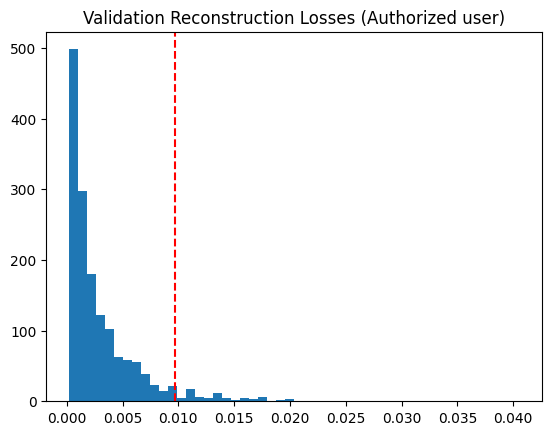

In [ ]:
#------------------------Second Implementation Continued------------------------
# compute threshold from validation set
user_recon_val = model.predict(X_val)
user_val_losses = tf.reduce_mean(tf.square(X_val - user_recon_val), axis=(1,2,3)).numpy()
threshold = np.percentile(user_val_losses, 95)  # 95th percentile threshold

print("Validation mean loss:", np.mean(user_val_losses))
print("Threshold (95th percentile):", threshold)

# Quick histogram (optional visual)
plt.hist(user_val_losses, bins=50)
plt.axvline(threshold, color='r', linestyle='--')
plt.title("Validation Reconstruction Losses (Authorized user)")
plt.show()

In [ ]:
#------------------------Second Implementation Continued------------------------
# Evaluation Helper functions to help evaluate a list of files and report metrics

def evaluate_files(file_list, name="Unnamed"):
    """Load each file, create RMS images, compute reconstruction losses, and report metrics."""
    print("\n--- EVALUATION:", name, "---")
    results = []
    for f in file_list:
        print("Processing:", os.path.basename(f))
        raw_emg, _, _ = load_ninapro_file(f)
        X_images = create_rms_images(raw_emg, window_samples, step_samples)
        X_images = X_images[..., np.newaxis]
        recon = model.predict(X_images)
        losses = tf.reduce_mean(tf.square(X_images - recon), axis=(1,2,3)).numpy()
        mean_loss = np.mean(losses)
        detections = losses > threshold
        detection_rate = np.mean(detections) * 100
        # report per-file
        print(f"  Num images: {len(losses)}, Mean loss: {mean_loss:.6f}, Detection rate: {detection_rate:.2f}%")
        results.append({
            'file': os.path.basename(f),
            'n_images': int(len(losses)),
            'mean_loss': float(mean_loss),
            'detection_rate_pct': float(detection_rate)
        })
    return results

In [ ]:
#------------------------Second Implementation Continued------------------------
# Evaluations against subjects 2 and 3 and against subject 1's holdout data and visualizations

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import json

# Evaluate subject 2:
res_s2 = evaluate_files(s2_files, name="Subject s2 (intruder)")
# Evaluate subject 3:
res_s3 = evaluate_files(s3_files, name="Subject s3 (intruder)")
# Evaluate subject 1 holdout data:
res_s1_holdout = evaluate_files([holdout_file_s1], name="Subject s1 holdout (should be accepted)")

# Optionally collect into one combined report
report = {
    's2': res_s2,
    's3': res_s3,
    's1_holdout': res_s1_holdout
}

# Print report summary (human-friendly)
#import json
#print("\n\n=== SUMMARY ===")
#print(json.dumps(report, indent=2))

# Visualizations
# Helper: convert list of .mat files to concatenated RMS images
def files_to_rms_array(file_list):
    emg_all, _, _ = load_selected_mat_files(file_list)
    rms_images = create_rms_images(emg_all, window_samples, step_samples)
    return rms_images[..., np.newaxis]  # Add channel dim

X_val = files_to_rms_array(train_files_s1)          # Authorized User (training)
X_s2 = files_to_rms_array(s2_files)                 # Intruder S2
X_s3 = files_to_rms_array(s3_files)                 # Intruder S3
X_s1_holdout = files_to_rms_array([holdout_file_s1]) # Held-out S1

# Ensure 4D arrays
def ensure_4d(X):
    return X if X.ndim == 4 else X[..., np.newaxis]

X_val = ensure_4d(X_val)
X_s2 = ensure_4d(X_s2)
X_s3 = ensure_4d(X_s3)
X_s1_holdout = ensure_4d(X_s1_holdout)

# Compute reconstruction errors
def compute_losses(model, X):
    recon = model.predict(X, verbose=0)
    return tf.reduce_mean(tf.square(X - recon), axis=(1,2,3)).numpy()

loss_val = compute_losses(model, X_val)
loss_s2 = compute_losses(model, X_s2)
loss_s3 = compute_losses(model, X_s3)
loss_s1_holdout = compute_losses(model, X_s1_holdout)

# Threshold: 95th percentile of authorized user
threshold = np.percentile(loss_val, 95)
print(f"\nThreshold (95th percentile of Authorized User): {threshold:.5f}")


--- EVALUATION: Subject s2 (intruder) ---
Processing: S2_E1_A1.mat
[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Num images: 7417, Mean loss: 0.012654, Detection rate: 43.89%
Processing: S2_E2_A1.mat
[LOAD] S2_E2_A1.mat -> EMG shape: (203945, 16)
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Num images: 10196, Mean loss: 0.007251, Detection rate: 25.61%
Processing: S2_E3_A1.mat
[LOAD] S2_E3_A1.mat -> EMG shape: (292932, 16)
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Num images: 14645, Mean loss: 0.008216, Detection rate: 28.33%

--- EVALUATION: Subject s3 (intruder) ---
Processing: S3_E1_A1.mat
[LOAD] S3_E1_A1.mat -> EMG shape: (131366, 16)
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Num images: 6567, Mean loss: 0.017384, Detection rate: 66.38%
Processing: S3_E2_A1.mat
[LOAD] S3_E2_A1.mat -> EMG shape: (184429, 16)
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Num images: 9220, Mean loss: 0.020350, Detection rate: 66.95%
Processing: S3_E3_A1.mat
[L

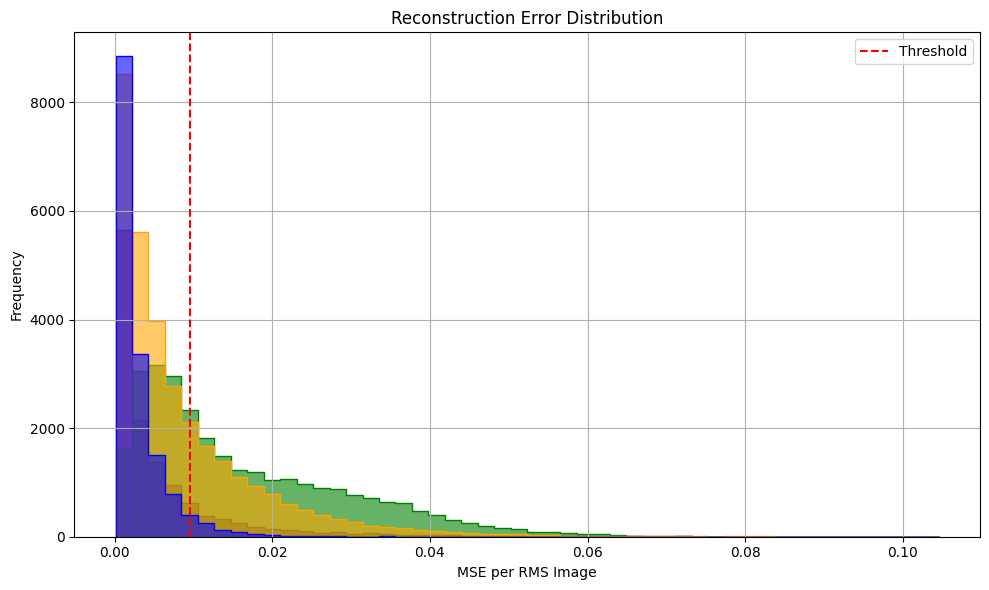

/tmp/ipython-input-3732421005.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_losses, x='Subject', y='MSE', palette=['blue','orange','green','purple'])


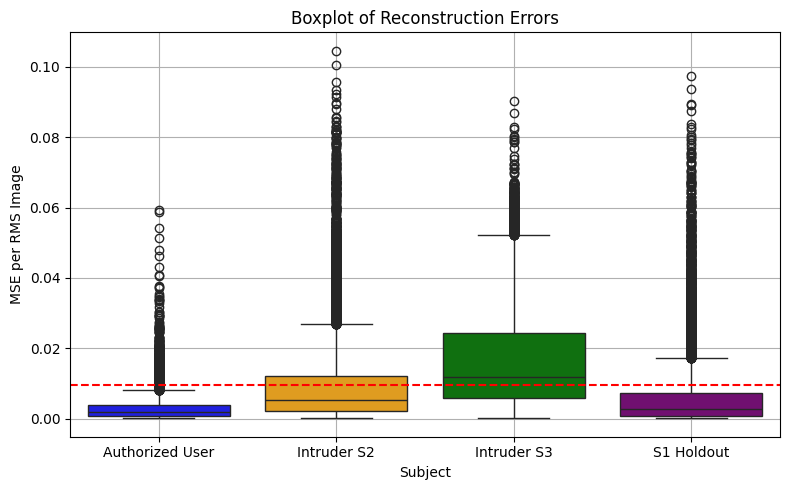

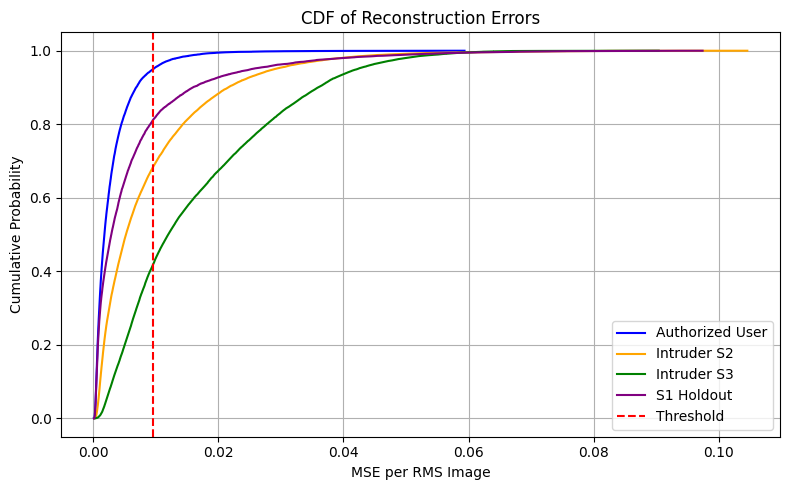

/tmp/ipython-input-3732421005.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(rates.keys()), y=list(rates.values()), palette=['orange','green','purple'])


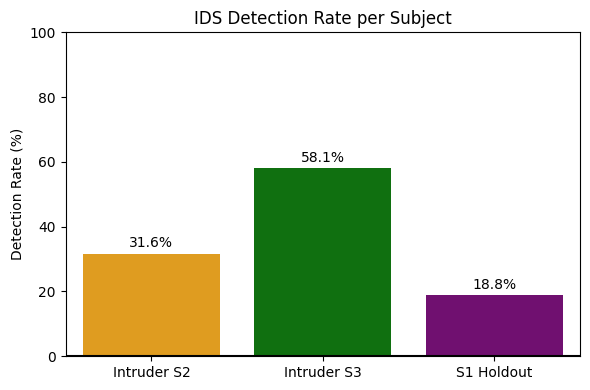

In [ ]:
#------------------------Second Implementation Continued------------------------
# Evaluation Visualizations

# Prepare long-form DataFrame
loss_data = []
for losses, subject in zip([loss_val, loss_s2, loss_s3, loss_s1_holdout],
                           ['Authorized User','Intruder S2','Intruder S3','S1 Holdout']):
    loss_data.extend([{'Subject': subject, 'MSE': l} for l in losses])
df_losses = pd.DataFrame(loss_data)

# Histogram per subject
plt.figure(figsize=(10,6))
sns.histplot(data=df_losses, x='MSE', hue='Subject', bins=50, palette=['blue','orange','green','purple'], alpha=0.6, element='step', stat='count')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE per RMS Image")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df_losses, x='Subject', y='MSE', palette=['blue','orange','green','purple'])
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("Boxplot of Reconstruction Errors")
plt.ylabel("MSE per RMS Image")
plt.grid(True)
plt.tight_layout()
plt.show()

# CDF
plt.figure(figsize=(8,5))
for subject, color in zip(['Authorized User','Intruder S2','Intruder S3','S1 Holdout'],
                          ['blue','orange','green','purple']):
    sorted_losses = np.sort(df_losses[df_losses['Subject']==subject]['MSE'].values)
    cdf = np.arange(len(sorted_losses))/len(sorted_losses)
    plt.plot(sorted_losses, cdf, label=subject, color=color)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("CDF of Reconstruction Errors")
plt.xlabel("MSE per RMS Image")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Detection rate per subject
rates = {subject: np.mean(df_losses[df_losses['Subject']==subject]['MSE'].values > threshold)*100
         for subject in ['Intruder S2','Intruder S3','S1 Holdout']}

plt.figure(figsize=(6,4))
sns.barplot(x=list(rates.keys()), y=list(rates.values()), palette=['orange','green','purple'])
plt.axhline(0, color='black')
plt.ylabel("Detection Rate (%)")
plt.title("IDS Detection Rate per Subject")
plt.ylim(0,100)
for i, v in enumerate(rates.values()):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()
#-------------------------END of Second Implementation--------------------------

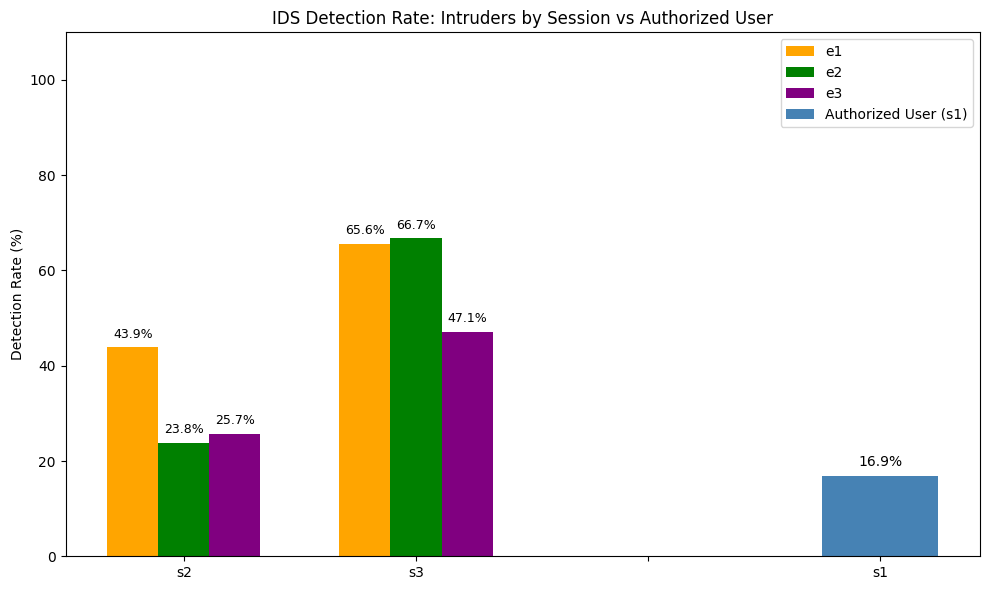

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Detection rates extracted from your evaluation logs
rates = {
    "s2": {"e1": 43.89, "e2": 23.83, "e3": 25.69},
    "s3": {"e1": 65.57, "e2": 66.72, "e3": 47.12},
    "s1": 16.89   # authorized user holdout detection rate
}

# Colors for e1/e2/e3
session_colors = {
    "e1": "orange",
    "e2": "green",
    "e3": "purple"
}

# Layout
subjects = ["s2", "s3", " ", "s1"]  # blank for spacing
x_positions = np.arange(len(subjects))
bar_width = 0.22

plt.figure(figsize=(10,6))

# Grouped bars for s2 and s3
for i, subj in enumerate(["s2", "s3"]):
    for j, session in enumerate(["e1", "e2", "e3"]):
        plt.bar(
            x_positions[i] + (j - 1) * bar_width,
            rates[subj][session],
            width=bar_width,
            color=session_colors[session],
            label=session if i == 0 else None
        )

# Single authorized user bar
plt.bar(
    x_positions[3],
    rates["s1"],
    width=0.5,
    color="steelblue",
    label="Authorized User (s1)"
)

# Formatting
plt.xticks(x_positions, subjects)
plt.ylabel("Detection Rate (%)")
plt.title("IDS Detection Rate: Intruders by Session vs Authorized User")
plt.ylim(0, 110)

# Add label values
for i, subj in enumerate(["s2", "s3"]):
    for j, session in enumerate(["e1", "e2", "e3"]):
        val = rates[subj][session]
        plt.text(
            x_positions[i] + (j - 1) * bar_width,
            val + 2,
            f"{val:.1f}%",
            ha='center',
            fontsize=9
        )

plt.text(
    x_positions[3],
    rates["s1"] + 2,
    f"{rates['s1']:.1f}%",
    ha='center',
    fontsize=10
)

plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
"""
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

def load_ninapro_file(file_path):
    try:
        data = scipy.io.loadmat(file_path, simplify_cells=True)

        # DB5 has 16 columns (2 Myo armbands x 8 sensors)
        # First eight is a higher armband, second eight is a lower armband
        # Since conv models do a sweeping window convolution function, need
        # upper band to calculate relative to lower band's same channels
        emg_signal = data['emg']
        stimulus = data['stimulus']
        repetition = data['repetition']

        print(f"Successfully loaded: {file_path}")
        print(f"EMG Shape: {emg_signal.shape} (Samples x Channels)")
        print(f"Labels Shape: {stimulus.shape}")

        return emg_signal, stimulus, repetition

    except Exception as e:
        print(f"Error loading file: {e}")
        return None, None, None
file_path = 's1/S1_E1_A1.mat'
#file_path = 'S1_E1_A1.mat'
emg, labels, reps = load_ninapro_file(file_path)

# First 1000 channels
plt.plot(emg[:1000, 0])
plt.title("Raw EMG Signal - Channel 1")
plt.show()
"""

'\nimport scipy.io\nimport numpy as np\nimport matplotlib.pyplot as plt\n\ndef load_ninapro_file(file_path):\n    try:\n        data = scipy.io.loadmat(file_path, simplify_cells=True)\n\n        # DB5 has 16 columns (2 Myo armbands x 8 sensors)\n        # First eight is a higher armband, second eight is a lower armband\n        # Since conv models do a sweeping window convolution function, need\n        # upper band to calculate relative to lower band\'s same channels\n        emg_signal = data[\'emg\']\n        stimulus = data[\'stimulus\']\n        repetition = data[\'repetition\']\n\n        print(f"Successfully loaded: {file_path}")\n        print(f"EMG Shape: {emg_signal.shape} (Samples x Channels)")\n        print(f"Labels Shape: {stimulus.shape}")\n\n        return emg_signal, stimulus, repetition\n\n    except Exception as e:\n        print(f"Error loading file: {e}")\n        return None, None, None\nfile_path = \'s1/S1_E1_A1.mat\'\n#file_path = \'S1_E1_A1.mat\'\nemg, labels, 

In [ ]:
"""
def create_rms_images(emg_data, window_size, step_size):

    Converts raw EMG signal (Samples x 16) into a series of RMS images (N x 2 x 8).

    Parameters:
    - emg_data: The raw numpy array from NinaPro (e.g., 100000 x 16)
    - window_size: Number of samples per window (e.g., 200ms * 200Hz = 40 samples)
    - step_size: How much to slide the window (overlap)


    rms_images = []

    for i in range(0, len(emg_data) - window_size, step_size):
        window = emg_data[i : i + window_size]

        rms_vector = np.sqrt(np.mean(window**2, axis=0))
        rms_image = rms_vector.reshape(2, 8)
        if np.max(rms_image) > 0:
             rms_image = rms_image / np.max(rms_image)
        rms_images.append(rms_image)
    return np.array(rms_images)

# NinaPro DB5 is sampled at 200Hz
# We generally want a window of ~200-300ms for gesture recognition
fs = 200
win_len_ms = 200
window_samples = int(fs * (win_len_ms / 1000)) # 40 samples
step_samples = 20 # 50% overlap

X_images = create_rms_images(emg, window_samples, step_samples)

print(f"Created {len(X_images)} images.")
print(f"Shape of single image: {X_images[0].shape}") # Should be (2, 8)

plt.imshow(X_images[100], cmap='hot', interpolation='nearest')
plt.title("RMS Heatmap (2 Bands x 8 Sensors)")
plt.colorbar(label="Muscle Activation Intensity")
plt.ylabel("Armband (Upper vs Lower)")
plt.xlabel("Sensor Position (Radial)")
plt.show()
"""


'\ndef create_rms_images(emg_data, window_size, step_size):\n\n    Converts raw EMG signal (Samples x 16) into a series of RMS images (N x 2 x 8).\n\n    Parameters:\n    - emg_data: The raw numpy array from NinaPro (e.g., 100000 x 16)\n    - window_size: Number of samples per window (e.g., 200ms * 200Hz = 40 samples)\n    - step_size: How much to slide the window (overlap)\n\n\n    rms_images = []\n\n    for i in range(0, len(emg_data) - window_size, step_size):\n        window = emg_data[i : i + window_size]\n\n        rms_vector = np.sqrt(np.mean(window**2, axis=0))\n        rms_image = rms_vector.reshape(2, 8)\n        if np.max(rms_image) > 0:\n             rms_image = rms_image / np.max(rms_image)\n        rms_images.append(rms_image)\n    return np.array(rms_images)\n\n# NinaPro DB5 is sampled at 200Hz\n# We generally want a window of ~200-300ms for gesture recognition\nfs = 200\nwin_len_ms = 200\nwindow_samples = int(fs * (win_len_ms / 1000)) # 40 samples\nstep_samples = 20 # 5

In [ ]:

from sklearn.model_selection import train_test_split
raw_emg_s1, labels_s1, reps_s1 = load_ninapro_file('s1/S1_E1_A1.mat')
all_images_s1 = create_rms_images(raw_emg_s1, window_samples, step_samples)

X_train_user, X_test_user = train_test_split(
    all_images_s1,
    test_size=0.2,
    random_state=42
)

# Assume X_train_user is your (N, 2, 8) data from Subject 1
# We must add the channel dimension to make it (N, 2, 8, 1) (and 1 is just greyscale channel, since color is expected in this type of model)
X_train_user = X_train_user[:,:,:, np.newaxis]
'''
# Train the autoencoder to reconstruction Subject 1's data perfectly
history = model.fit(
    X_train_user, X_train_user, # Input and Target are the same!
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)
'''


[LOAD] S1_E1_A1.mat -> EMG shape: (130267, 16)


"\n# Train the autoencoder to reconstruction Subject 1's data perfectly\nhistory = model.fit(\n    X_train_user, X_train_user, # Input and Target are the same!\n    epochs=50,\n    batch_size=32,\n    validation_split=0.1,\n    shuffle=True\n)\n"

In [ ]:
# --- STEP 4: Load the Intruder (Subject 2) ---
# The model NEVER sees this during training.
raw_emg_s2, _, _ = load_ninapro_file('s2/S2_E1_A1.mat')
X_intruder = create_rms_images(raw_emg_s2, window_samples, step_samples)

[LOAD] S2_E1_A1.mat -> EMG shape: (148367, 16)


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Average Normal Error: 0.00265
Security Threshold (95%): 0.00775


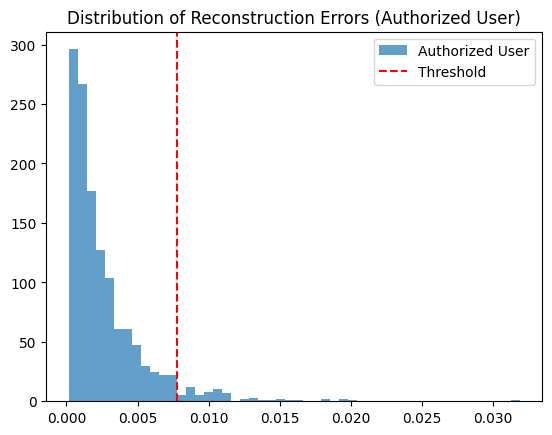

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the Data (Add channel dimension if not already done)
# We assume X_test_user (Auth User) and X_intruder (Subject 2) exist from previous steps
if X_test_user.ndim == 3:
    X_test_user = X_test_user[..., np.newaxis]
if X_intruder.ndim == 3:
    X_intruder = X_intruder[..., np.newaxis]

# 2. Get Reconstruction Error for the VALID User
# The model attempts to reconstruct the user's own validation data
user_reconstructions = model.predict(X_test_user)
# Calculate Mean Squared Error (MSE) for each image individually
user_losses = tf.reduce_mean(tf.square(X_test_user - user_reconstructions), axis=(1, 2, 3))

# 3. Define the Threshold (The "Bouncer's Limit")
# We set the limit at the 95th percentile of the user's normal error.
# Anything higher than this is considered suspicious.
threshold = np.percentile(user_losses, 95)


print(f"Average Normal Error: {np.mean(user_losses):.5f}")
print(f"Security Threshold (95%): {threshold:.5f}")

# Visual Check: Plot the histogram of normal errors
plt.hist(user_losses, bins=50, alpha=0.7, label='Authorized User')
plt.axvline(threshold, color='r', linestyle='dashed', label='Threshold')
plt.legend()
plt.title("Distribution of Reconstruction Errors (Authorized User)")
plt.show()

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Average Intruder Error: 0.01265
IDS Detection Success Rate: 51.54%


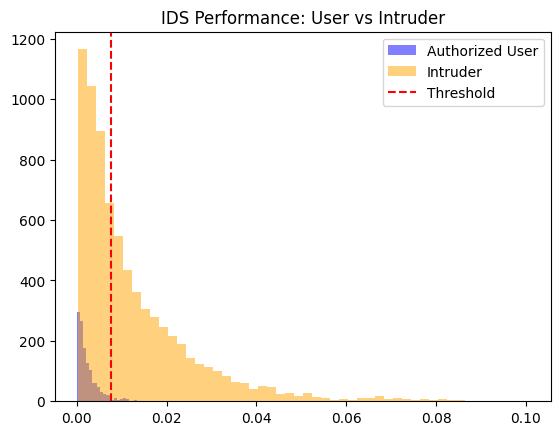

In [ ]:
# Predict on Intruder Data
intruder_reconstructions = model.predict(X_intruder)

#Calculate Intruder Error
intruder_losses = tf.reduce_mean(tf.square(X_intruder - intruder_reconstructions), axis=(1, 2, 3))

# Determine Detection Rate
# A "Detection" is when the error exceeds our threshold
detections = intruder_losses > threshold
detection_rate = np.mean(detections) * 100

print(f"Average Intruder Error: {np.mean(intruder_losses):.5f}")
print(f"IDS Detection Success Rate: {detection_rate:.2f}%")

# Visual Check: Compare distributions
plt.hist(user_losses, bins=50, alpha=0.5, label='Authorized User', color='blue')
plt.hist(intruder_losses, bins=50, alpha=0.5, label='Intruder', color='orange')
plt.axvline(threshold, color='r', linestyle='dashed', label='Threshold')
plt.title("IDS Performance: User vs Intruder")
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
def make_gradcam_heatmap(model, img_array, layer_name):
    """
    Generates a Grad-CAM heatmap representing the contribution to Reconstruction Error.
    """
    # 1. Create a model that maps the input image to the activations
    #    of the target conv layer AND the final reconstruction.
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    # 2. Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Forward pass
        conv_outputs, reconstruction = grad_model(img_array)

        # Calculate the Reconstruction Loss (MSE) manually here
        # We want to know what drives this specific error value
        loss = tf.reduce_mean(tf.square(img_array - reconstruction))

    # 3. Compute Gradients of the LOSS with respect to the CONV OUTPUTS
    grads = tape.gradient(loss, conv_outputs)

    # 4. Global Average Pooling of Gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Weighted Sum of Feature Maps
    conv_outputs = conv_outputs[0] # Remove batch dimension

    # Initialize heatmap
    heatmap = tf.zeros(shape=conv_outputs.shape[:2])

    for i in range(pooled_grads.shape[-1]):
        heatmap += pooled_grads[i] * conv_outputs[:, :, i]

    # 6. Apply ReLU (We only care about positive influence on Error)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()


def plot_xai_analysis(original, reconstructed, heatmap):
    """
    Visualizes the Input, Reconstruction, and the Explanation (Heatmap).
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))

    # 1. Original Input (The raw gesture)
    # .squeeze() removes the extra dimensions (1, 2, 8, 1) -> (2, 8)
    axes[0].imshow(original.squeeze(), cmap='viridis', vmin=0, vmax=1)
    axes[0].set_title("Original Input (User Gesture)")
    axes[0].set_xlabel("Sensors")
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(["Upper", "Lower"])

    #Reconstruction (What the model 'thought' it saw)
    axes[1].imshow(reconstructed.squeeze(), cmap='viridis', vmin=0, vmax=1)
    axes[1].set_title("Reconstruction (Model Output)")
    axes[1].set_yticks([]) # Hide y-axis labels for cleaner look

    # XAI Heatmap (Where the anomaly is)
    # We resize the small heatmap to match the 2x8 input size using OpenCV
    heatmap_resized = cv2.resize(heatmap, (8, 2))

    # Plot the heatmap overlaid on the original
    axes[2].imshow(original.squeeze(), cmap='gray', alpha=0.5)
    im3 = axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.6) # 'jet' = Red is High Error
    axes[2].set_title("XAI Anomaly Map (Grad-CAM)")
    axes[2].set_yticks([])

    plt.colorbar(im3, ax=axes[2], label="Anomaly Contribution")
    plt.tight_layout()
    plt.show()


In [ ]:
# 1. Select a specific "Caught" Intruder Sample
# Find indices where the intruder was correctly detected
caught_indices = np.where(detections)[0]
sample_idx = caught_indices[0] # Let's look at the first one caught

input_image = X_intruder[sample_idx:sample_idx+1] # Shape (1, 2, 8, 1)

# 2. Generate the Heatmap
target_layer = 'conv2d_3'

try:
    heatmap = make_gradcam_heatmap(model, input_image, target_layer)
    reconstruction = model.predict(input_image)

    # 3. Visualize using the function we wrote previously
    print(f"Analyzing Intrusion Sample #{sample_idx}")
    print(f"Error Score: {intruder_losses[sample_idx]:.5f} (Threshold: {threshold:.5f})")
    plot_xai_analysis(input_image, reconstruction, heatmap)

except ValueError as e:
    print(f"Layer name error! Check model.summary(). Detailed error: {e}")

Layer name error! Check model.summary(). Detailed error: No such layer: conv2d_3. Existing layers are: ['input_layer_2', 'conv2d_4', 'batch_normalization_2', 'conv2d_5', 'flatten_2', 'latent_space', 'dense_2', 'reshape_2', 'conv2d_transpose_4', 'conv2d_transpose_5', 'output'].


Loading S1 Data with Per-Image Normalization...
Training Model...
New Threshold (95th Percentile): 0.02324
Testing Intruders...


/tmp/ipython-input-2574040378.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subjects, y=values, palette=colors)
/tmp/ipython-input-2574040378.py:193: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


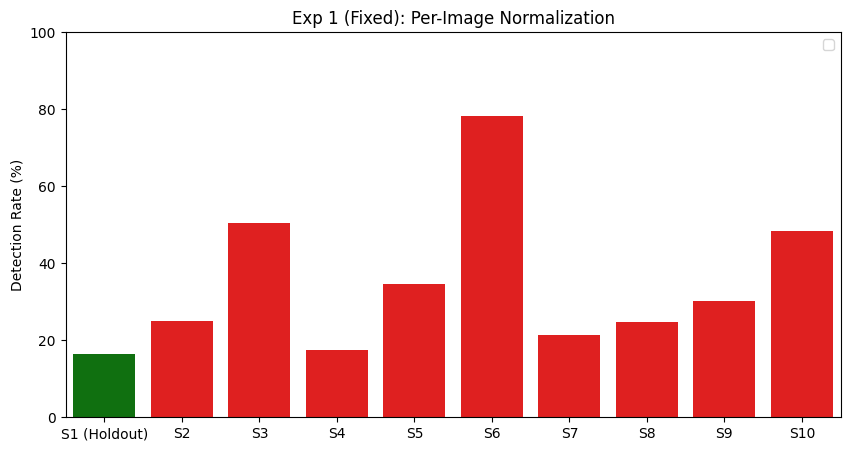

In [ ]:
import os
import glob
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ==========================================
# 1. CONFIGURATION & HELPERS
# ==========================================
FS = 200
WINDOW_SAMPLES = 40  # 200ms
STEP_SAMPLES = 20    # 50% overlap (100ms)

def load_ninapro_file(file_path):
    """Robust MAT file loader"""
    try:
        data = scipy.io.loadmat(file_path, simplify_cells=True)
        # Handle variations in key names
        for key in ['emg', 'EMG', 'emg_signal']:
            if key in data:
                return data[key], None, None
        raise KeyError("EMG data not found")
    except Exception as e:
        print(f"Skipping {os.path.basename(file_path)}: {e}")
        return None, None, None

def get_subject_files(subject_index, base_dir='/content'):
    """Get all .mat files for a specific subject folder (s1, s2... s10)"""
    path = os.path.join(base_dir, f's{subject_index}')
    return sorted(glob.glob(os.path.join(path, '*.mat')))

def find_global_max(subject_indices=range(1, 11)):
    """Scans ALL files to find the single highest peak for normalization"""
    print("Scanning dataset for Global Max (normalization factor)...")
    global_max = 0
    for i in subject_indices:
        files = get_subject_files(i)
        for f in files:
            emg, _, _ = load_ninapro_file(f)
            if emg is not None:
                # We only need RMS of windows, not full reshaping yet
                # Fast vectorized RMS calculation
                # Truncate to fit windows
                n_windows = (emg.shape[0] - WINDOW_SAMPLES) // STEP_SAMPLES + 1
                if n_windows < 1: continue

                # Shape for striding: (N_Windows, Window_Size, 16)
                shape = (n_windows, WINDOW_SAMPLES, emg.shape[1])
                strides = (emg.strides[0] * STEP_SAMPLES, emg.strides[0], emg.strides[1])
                windows = np.lib.stride_tricks.as_strided(emg, shape=shape, strides=strides)

                # RMS per window per channel
                rms = np.sqrt(np.mean(windows**2, axis=1))

                # Update global max
                file_max = np.max(rms)
                if file_max > global_max:
                    global_max = file_max
    print(f"Global Max RMS found: {global_max:.4f}")
    return global_max

def files_to_norm_images(file_list, global_max_val):
    """Converts files -> RMS Images -> Normalized by Global Max"""
    all_images = []
    for f in file_list:
        emg, _, _ = load_ninapro_file(f)
        if emg is None: continue

        # Windowing loop
        for i in range(0, len(emg) - WINDOW_SAMPLES, STEP_SAMPLES):
            window = emg[i : i + WINDOW_SAMPLES]
            rms_vector = np.sqrt(np.mean(window**2, axis=0))

            # Reshape 16 -> 2x8
            rms_image = rms_vector.reshape(2, 8)
            all_images.append(rms_image)

    # Convert to array and Normalize globally
    X = np.array(all_images)
    if global_max_val > 0:
        X = X / global_max_val
    return X[..., np.newaxis] # Add channel dim (N, 2, 8, 1)

def build_constrained_model():
    """Builds the 'Second Implementation' Spatial Autoencoder with constraints"""
    input_img = layers.Input(shape=(2, 8, 1))

    # Encoder
    x = layers.Conv2D(16, (2, 2), padding='same', activation='relu')(input_img)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Conv2D(8, (2, 2), strides=(1, 2), padding='same', activation='relu')(x)
    x = layers.Flatten()(x)

    # Sparse Bottleneck
    encoded = layers.Dense(4, activation='relu',
                           activity_regularizer=regularizers.l1(1e-4))(x)

    # Decoder
    x = layers.Dense(8*2*4, activation='relu')(encoded) # Calc based on shapes
    x = layers.Reshape((2, 4, 8))(x)
    x = layers.Conv2DTranspose(8, (2, 2), strides=(1, 2), padding='same', activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Conv2DTranspose(16, (2, 2), padding='same', activation='relu')(x)
    decoded = layers.Conv2D(1, (2, 2), activation='sigmoid', padding='same')(x)

    model = models.Model(input_img, decoded)
    model.compile(optimizer='adam', loss='mse')
    return model

# ==========================================
# 2. EXECUTION: EXPERIMENT 1 (Fixed Normalization)
# ==========================================

# Redefine Image Creator to use PER-IMAGE Normalization (Like the 2nd Implementation)
def files_to_per_image_norm(file_list):
    """Converts files -> RMS Images -> Normalized INDIVIDUALLY (0 to 1)"""
    all_images = []
    for f in file_list:
        emg, _, _ = load_ninapro_file(f)
        if emg is None: continue

        # Windowing
        for i in range(0, len(emg) - WINDOW_SAMPLES, STEP_SAMPLES):
            window = emg[i : i + WINDOW_SAMPLES]
            rms_vector = np.sqrt(np.mean(window**2, axis=0))

            # Reshape 16 -> 2x8
            rms_image = rms_vector.reshape(2, 8)

            # --- PER-IMAGE NORMALIZATION ---
            # This ensures every gesture looks "bright" to the model
            local_max = np.max(rms_image)
            if local_max > 0:
                rms_image = rms_image / local_max

            all_images.append(rms_image)

    return np.array(all_images)[..., np.newaxis]

# --- Setup Data ---
print("Loading S1 Data with Per-Image Normalization...")
s1_files = get_subject_files(1)
X_train = files_to_per_image_norm(s1_files[:2])      # Train on File 1 & 2
X_val_holdout = files_to_per_image_norm([s1_files[2]]) # Test on File 3

# --- Train Model ---
# We use the constrained model to keep the "fingerprint" tight
model = build_constrained_model()
print("Training Model...")
model.fit(X_train, X_train, epochs=20, batch_size=32, verbose=0, shuffle=True)

# --- Calculate Threshold ---
# We use Percentile (stricter) instead of Mean+Std
train_recon = model.predict(X_train, verbose=0)
train_losses = tf.reduce_mean(tf.square(X_train - train_recon), axis=(1,2,3)).numpy()
threshold = np.percentile(train_losses, 95) # 95% Acceptance for S1
print(f"New Threshold (95th Percentile): {threshold:.5f}")

# --- Evaluate 9 Intruders ---
detection_rates = {}

# Check S1 Holdout
recon = model.predict(X_val_holdout, verbose=0)
loss = tf.reduce_mean(tf.square(X_val_holdout - recon), axis=(1,2,3)).numpy()
detection_rates['S1 (Holdout)'] = np.mean(loss > threshold) * 100

# Check Intruders S2-S10
print("Testing Intruders...")
for i in range(2, 11):
    files = get_subject_files(i)
    if not files: continue
    # Normalize intruders the same way (Per-Image)
    X_intruder = files_to_per_image_norm(files)

    recon = model.predict(X_intruder, verbose=0)
    loss = tf.reduce_mean(tf.square(X_intruder - recon), axis=(1,2,3)).numpy()
    detection_rates[f'S{i}'] = np.mean(loss > threshold) * 100

# --- Plot ---
plt.figure(figsize=(10, 5))
subjects = list(detection_rates.keys())
values = list(detection_rates.values())
colors = ['green'] + ['red'] * (len(values)-1)

sns.barplot(x=subjects, y=values, palette=colors)
plt.title("Exp 1 (Fixed): Per-Image Normalization")
plt.ylabel("Detection Rate (%)")
plt.ylim(0, 100)
plt.legend()
plt.show()




--- Running S1 Cross-Validation (Detailed Breakdown) ---
Loading and processing intruder data (S2-S10)...

Processing Holdout File 1...

Processing Holdout File 2...

Processing Holdout File 3...


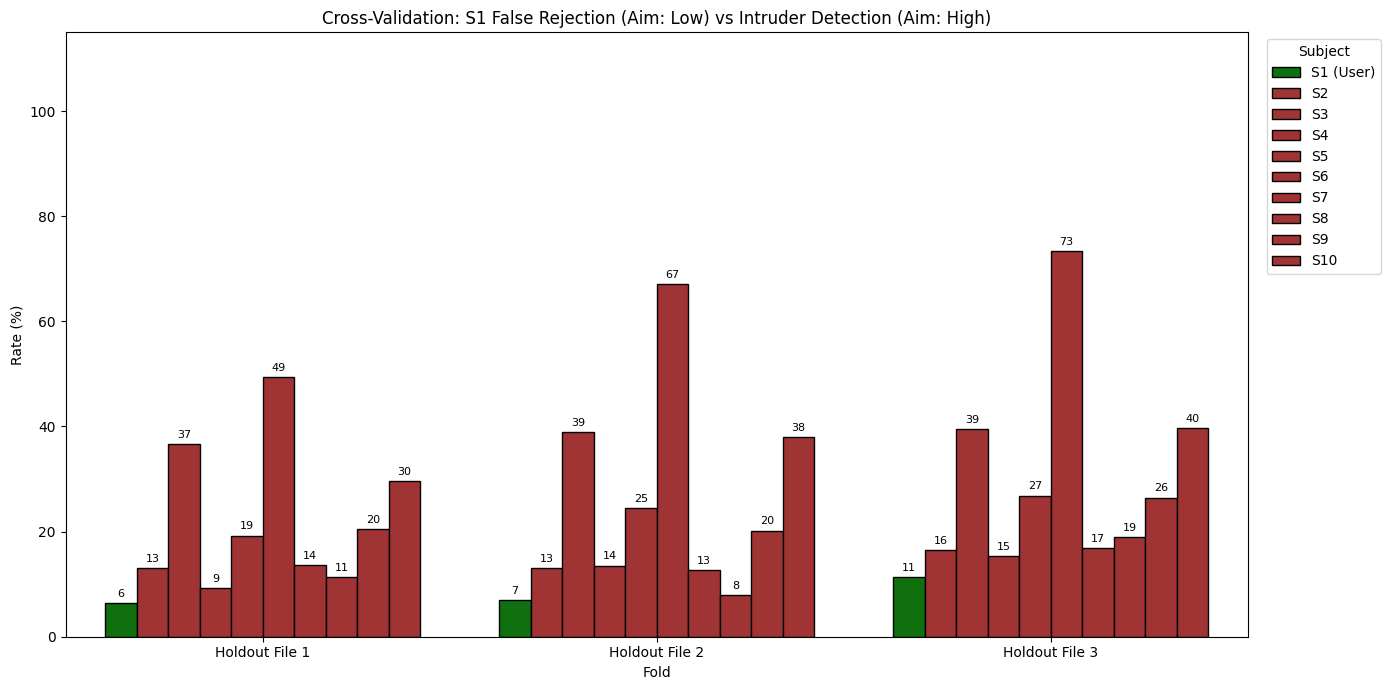

In [ ]:
# ==========================================
# 3. EXECUTION: EXPERIMENT 2 (Detailed Cross-Validation) - UPDATED
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

print("\n--- Running S1 Cross-Validation (Detailed Breakdown) ---")

# 1. Prepare Data Containers
# We store intruders separately to track individual detection rates
print("Loading and processing intruder data (S2-S10)...")
intruder_data = {}
for i in range(2, 11):
    files = get_subject_files(i)
    if files:
        # Use Per-Image Normalization
        intruder_data[f'S{i}'] = files_to_per_image_norm(files)

# Load S1 Files
s1_files = get_subject_files(1)
cv_detailed_results = []

# 2. Cross-Validation Loop
for i in range(len(s1_files)):
    fold_name = f"Holdout File {i+1}"
    print(f"\nProcessing {fold_name}...")

    # A. Split Data
    test_file = [s1_files[i]]
    train_files = [f for j, f in enumerate(s1_files) if j != i]

    X_train = files_to_per_image_norm(train_files)
    X_test_holdout = files_to_per_image_norm(test_file)

    # B. Train Model (Fresh model for each fold)
    model_cv = build_constrained_model()
    model_cv.fit(X_train, X_train, epochs=20, batch_size=32, verbose=0, shuffle=True)

    # C. Calculate Threshold (95th Percentile of Train Error)
    train_recon = model_cv.predict(X_train, verbose=0)
    train_losses = tf.reduce_mean(tf.square(X_train - train_recon), axis=(1,2,3)).numpy()
    fold_thresh = np.percentile(train_losses, 95)

    # D. Evaluate S1 (False Rejection Rate)
    # We want this to be LOW
    holdout_recon = model_cv.predict(X_test_holdout, verbose=0)
    holdout_loss = tf.reduce_mean(tf.square(X_test_holdout - holdout_recon), axis=(1,2,3)).numpy()
    frr = np.mean(holdout_loss > fold_thresh) * 100

    cv_detailed_results.append({
        'Fold': fold_name,
        'Subject': 'S1 (User)',
        'Type': 'False Rejection',
        'Rate': frr
    })

    # E. Evaluate Intruders (Detection Rate)
    # We want these to be HIGH
    for subj_name, X_int in intruder_data.items():
        int_recon = model_cv.predict(X_int, verbose=0)
        int_loss = tf.reduce_mean(tf.square(X_int - int_recon), axis=(1,2,3)).numpy()
        tar = np.mean(int_loss > fold_thresh) * 100

        cv_detailed_results.append({
            'Fold': fold_name,
            'Subject': subj_name,
            'Type': 'Intruder Detection',
            'Rate': tar
        })

# 3. Visualization
df_res = pd.DataFrame(cv_detailed_results)

# Create a custom color palette
# Only 'S1 (User)' should be green. Everything else is red.
unique_subjs = ['S1 (User)'] + [f'S{k}' for k in range(2, 11)]
palette = {subj: 'green' if subj == 'S1 (User)' else 'firebrick' for subj in unique_subjs}

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_res,
    x='Fold',
    y='Rate',
    hue='Subject',
    palette=palette,
    edgecolor='black'
)

# Add Value Labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)

plt.title("Cross-Validation: S1 False Rejection (Aim: Low) vs Intruder Detection (Aim: High)")
plt.ylabel("Rate (%)")
plt.ylim(0, 115)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Subject")
plt.tight_layout()
plt.show()


=== EXPERIMENT 3: Group Authentication (S1, S2, S3 Authorized) ===
Loading Group Data...
Training on 48906 samples from S1, S2, S3...
Group Threshold (95%): 0.03067
Evaluating Authorized Holdouts...
Evaluating Intruders...


/tmp/ipython-input-3432738602.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=keys, y=vals, palette=colors)
/tmp/ipython-input-3432738602.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


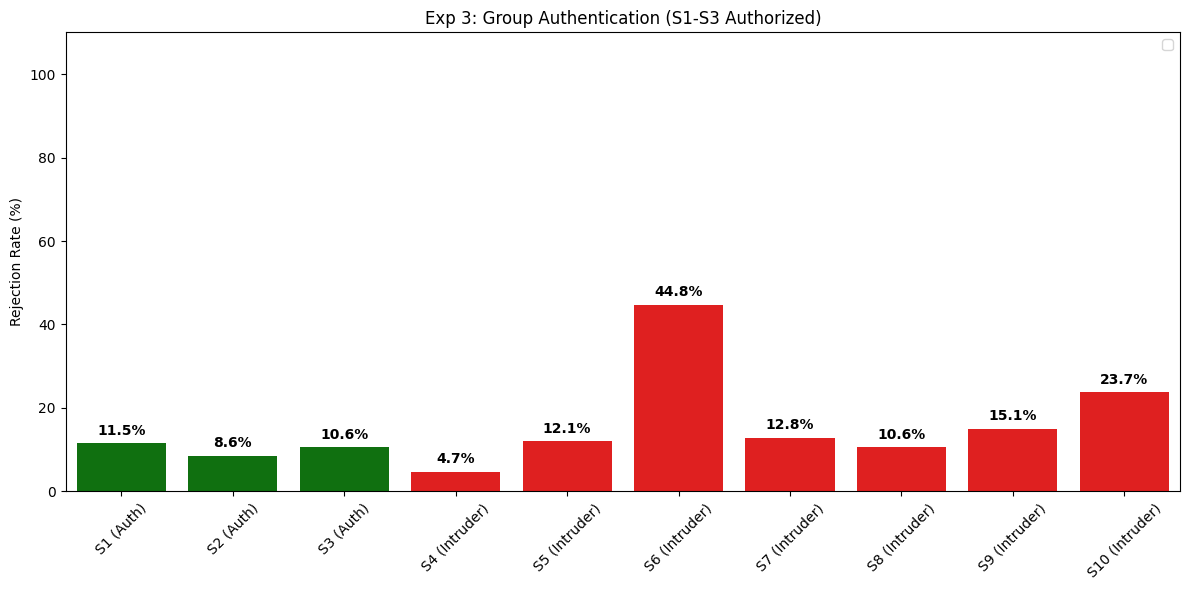

In [ ]:
# ==========================================
# 4. EXECUTION: EXPERIMENT 3 (Group Authentication: S1+S2+S3) - WITH LABELS
# ==========================================
print("\n=== EXPERIMENT 3: Group Authentication (S1, S2, S3 Authorized) ===")

# 1. Define Groups
auth_subjects = [1, 2, 3]
intruder_subjects = list(range(4, 11))

# 2. Prepare Data (Using PER-IMAGE Normalization)
print("Loading Group Data...")
train_files_group = []
holdout_files_group = []

for s in auth_subjects:
    files = get_subject_files(s)
    # Train on Files 1 & 2
    train_files_group.extend(files[:2])
    # Test on File 3
    holdout_files_group.extend([files[2]])

X_train_group = files_to_per_image_norm(train_files_group)

# 3. Train Model
model_group = build_constrained_model()
print(f"Training on {len(X_train_group)} samples from S1, S2, S3...")
model_group.fit(X_train_group, X_train_group, epochs=25, batch_size=32, verbose=0, shuffle=True)

# 4. Threshold (Fixed to 95th Percentile)
recon_train = model_group.predict(X_train_group, verbose=0)
losses_train = tf.reduce_mean(tf.square(X_train_group - recon_train), axis=(1,2,3)).numpy()
thresh_group = np.percentile(losses_train, 95)
print(f"Group Threshold (95%): {thresh_group:.5f}")

# 5. Evaluate
group_results = {}

# Check Authorized Users (Holdout Files)
print("Evaluating Authorized Holdouts...")
for i, f in zip(auth_subjects, holdout_files_group):
    X_holdout = files_to_per_image_norm([f])
    recon = model_group.predict(X_holdout, verbose=0)
    loss = tf.reduce_mean(tf.square(X_holdout - recon), axis=(1,2,3)).numpy()
    group_results[f'S{i} (Auth)'] = np.mean(loss > thresh_group) * 100

# Check Intruders
print("Evaluating Intruders...")
for i in intruder_subjects:
    files = get_subject_files(i)
    X_intruder = files_to_per_image_norm(files)
    recon = model_group.predict(X_intruder, verbose=0)
    loss = tf.reduce_mean(tf.square(X_intruder - recon), axis=(1,2,3)).numpy()
    group_results[f'S{i} (Intruder)'] = np.mean(loss > thresh_group) * 100

# 6. Plot Experiment 3
plt.figure(figsize=(12, 6)) # Increased height slightly for labels
keys = list(group_results.keys())
vals = list(group_results.values())
colors = ['green' if 'Auth' in k else 'red' for k in keys]

ax = sns.barplot(x=keys, y=vals, palette=colors)

# --- Add Labels ---
for i, v in enumerate(vals):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.title("Exp 3: Group Authentication (S1-S3 Authorized)")
plt.ylabel("Rejection Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 110) # Added headroom for labels
plt.legend()
plt.tight_layout()
plt.show()





=== EXPERIMENT 4: S1 Full Knowledge (No Holdout) vs All Intruders ===
Training Full Knowledge Model...
Full Knowledge Threshold (95%): 0.03060
Testing All Intruders...


/tmp/ipython-input-1652073521.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=keys, y=vals, palette='magma')
/tmp/ipython-input-1652073521.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


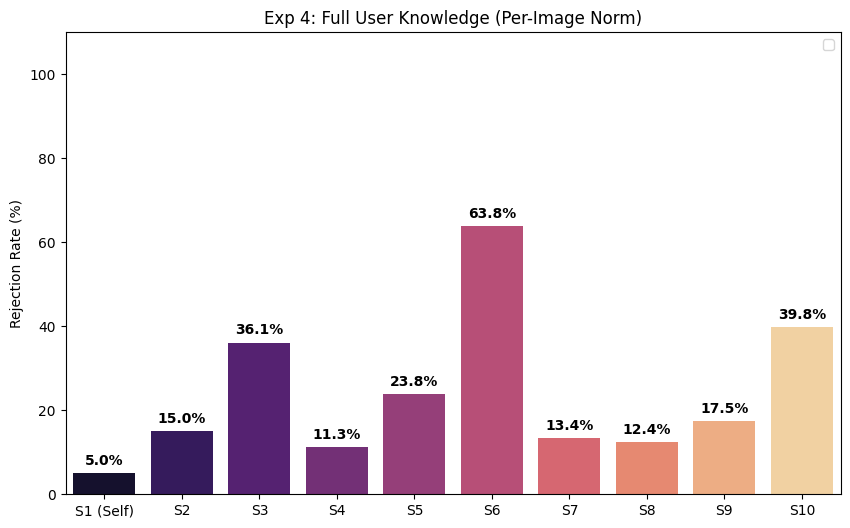

In [ ]:
# ==========================================
# 5. EXECUTION: EXPERIMENT 4 (S1 Full Knowledge) - WITH LABELS
# ==========================================
print("\n=== EXPERIMENT 4: S1 Full Knowledge (No Holdout) vs All Intruders ===")

# 1. Setup Data (Train on ALL 3 files)
s1_files_all = get_subject_files(1)
X_train_full = files_to_per_image_norm(s1_files_all)

# 2. Train
model_full = build_constrained_model()
print("Training Full Knowledge Model...")
model_full.fit(X_train_full, X_train_full, epochs=25, batch_size=32, verbose=0, shuffle=True)

# 3. Threshold (95th Percentile)
recon_full = model_full.predict(X_train_full, verbose=0)
losses_full = tf.reduce_mean(tf.square(X_train_full - recon_full), axis=(1,2,3)).numpy()
thresh_full = np.percentile(losses_full, 95)
print(f"Full Knowledge Threshold (95%): {thresh_full:.5f}")

# 4. Evaluate
full_results = {}

# S1 Self-Test
full_results['S1 (Self)'] = np.mean(losses_full > thresh_full) * 100

# S2-S10 Intruders
print("Testing All Intruders...")
for i in range(2, 11):
    files = get_subject_files(i)
    X_intruder = files_to_per_image_norm(files)
    recon = model_full.predict(X_intruder, verbose=0)
    loss = tf.reduce_mean(tf.square(X_intruder - recon), axis=(1,2,3)).numpy()
    full_results[f'S{i}'] = np.mean(loss > thresh_full) * 100

# 5. Plot Experiment 4
plt.figure(figsize=(10, 6))
keys = list(full_results.keys())
vals = list(full_results.values())

ax = sns.barplot(x=keys, y=vals, palette='magma')

# --- Add Labels ---
for i, v in enumerate(vals):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.title("Exp 4: Full User Knowledge (Per-Image Norm)")
plt.ylabel("Rejection Rate (%)")
plt.ylim(0, 110) # Added headroom
plt.legend()
plt.show()


=== EXPERIMENT 5: Extreme Holdout (Train on 1 File, Test on 2) ===

Fold [Held: 1 & 2] -> Training on ['S1_E3_A1.mat']...
  Threshold: 0.04284

Fold [Held: 1 & 3] -> Training on ['S1_E2_A1.mat']...
  Threshold: 0.02594

Fold [Held: 2 & 3] -> Training on ['S1_E1_A1.mat']...
  Threshold: 0.02270


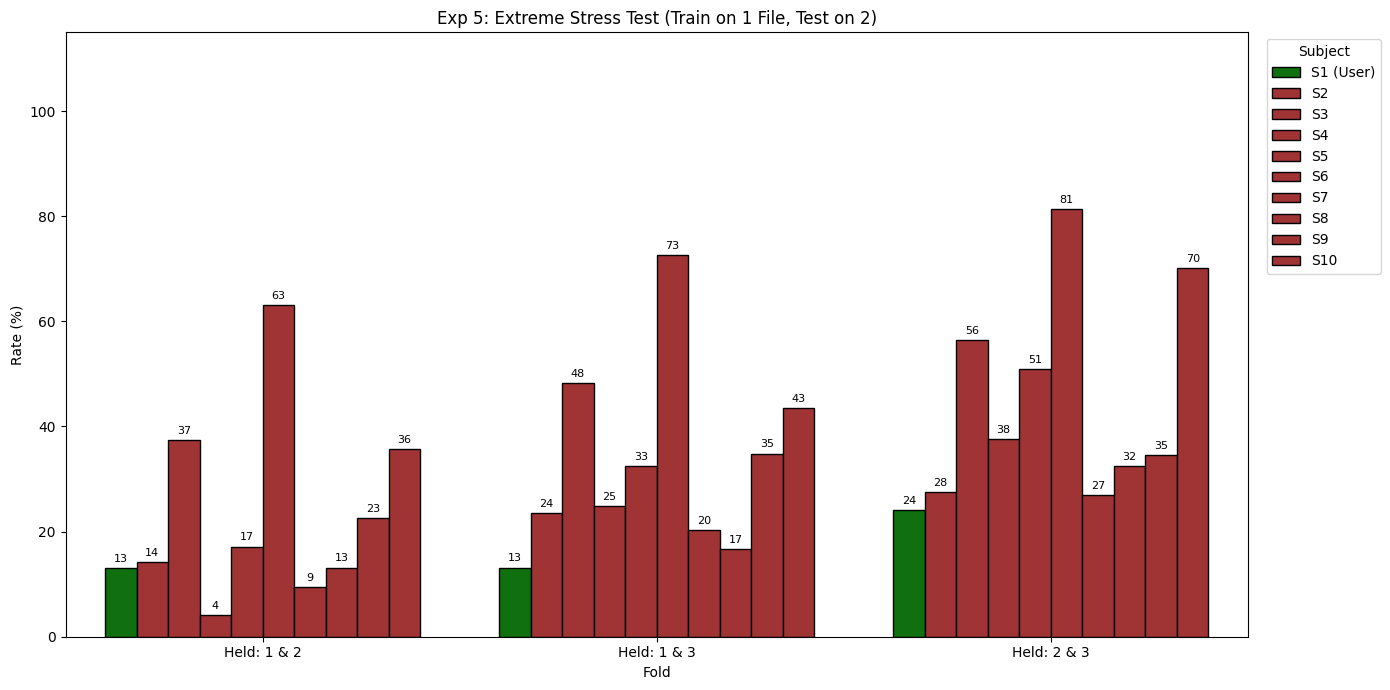

In [ ]:
# ==========================================
# 6. EXECUTION: EXPERIMENT 5 (Extreme Stress Test - Holdout 2 Files)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from itertools import combinations

print("\n=== EXPERIMENT 5: Extreme Holdout (Train on 1 File, Test on 2) ===")

# 1. Prepare Intruder Data (Once)
if 'intruder_data' not in locals():
    print("Loading intruder data...")
    intruder_data = {}
    for i in range(2, 11):
        files = get_subject_files(i)
        if files:
            intruder_data[f'S{i}'] = files_to_per_image_norm(files)

# Load S1 Files
s1_files = get_subject_files(1)
exp5_results = []

# 2. Generate Splits (Choose 2 files to hold out from the list)
# If S1 has [A, B, C], combinations are (A,B), (A,C), (B,C)
# This implies we TRAIN on C, B, A respectively.
indices = range(len(s1_files))
holdout_combos = list(combinations(indices, 2))

for holdout_idx in holdout_combos:
    # Identify Train vs Holdout
    holdout_files = [s1_files[i] for i in holdout_idx]
    train_files = [s1_files[i] for i in indices if i not in holdout_idx]

    # Naming for the graph (e.g., "Held: 1 & 2")
    # Adding 1 to index to match file names (File 1, File 2...)
    fold_label = f"Held: {holdout_idx[0]+1} & {holdout_idx[1]+1}"
    print(f"\nFold [{fold_label}] -> Training on {[os.path.basename(f) for f in train_files]}...")

    # A. Process Data
    X_train = files_to_per_image_norm(train_files)
    X_holdout = files_to_per_image_norm(holdout_files)

    # B. Train Model (Constrained)
    model_stress = build_constrained_model()
    # Training on only 1 file might require fewer epochs to avoid overfitting noise,
    # but we stick to 20 for consistency.
    model_stress.fit(X_train, X_train, epochs=20, batch_size=32, verbose=0, shuffle=True)

    # C. Threshold (95th Percentile of the single training file)
    recon_train = model_stress.predict(X_train, verbose=0)
    losses_train = tf.reduce_mean(tf.square(X_train - recon_train), axis=(1,2,3)).numpy()
    stress_thresh = np.percentile(losses_train, 95)
    print(f"  Threshold: {stress_thresh:.5f}")

    # D. Evaluate S1 (False Rejection on 2 unknown files)
    recon_holdout = model_stress.predict(X_holdout, verbose=0)
    loss_holdout = tf.reduce_mean(tf.square(X_holdout - recon_holdout), axis=(1,2,3)).numpy()
    frr = np.mean(loss_holdout > stress_thresh) * 100

    exp5_results.append({
        'Fold': fold_label,
        'Subject': 'S1 (User)',
        'Type': 'False Rejection',
        'Rate': frr
    })

    # E. Evaluate Intruders (Detection Rate)
    for subj_name, X_int in intruder_data.items():
        recon_int = model_stress.predict(X_int, verbose=0)
        loss_int = tf.reduce_mean(tf.square(X_int - recon_int), axis=(1,2,3)).numpy()
        tar = np.mean(loss_int > stress_thresh) * 100

        exp5_results.append({
            'Fold': fold_label,
            'Subject': subj_name,
            'Type': 'Intruder Detection',
            'Rate': tar
        })

# 3. Visualization
df_exp5 = pd.DataFrame(exp5_results)

# Custom Palette
unique_subjs = ['S1 (User)'] + [f'S{k}' for k in range(2, 11)]
palette = {subj: 'green' if subj == 'S1 (User)' else 'firebrick' for subj in unique_subjs}

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_exp5,
    x='Fold',
    y='Rate',
    hue='Subject',
    palette=palette,
    edgecolor='black'
)
# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)

plt.title("Exp 5: Extreme Stress Test (Train on 1 File, Test on 2)")
plt.ylabel("Rate (%)")
plt.ylim(0, 115)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Subject")
plt.tight_layout()
plt.show()